# 05 · Interpretabilidad AD — VAE + Clasificador (paper-ready)

**Pipeline:** VAE→latente μ + (Age, Sex) → clasificador `logreg` → SHAP (frozen/unfrozen) + saliency IG

**Flujo paper:** `Kernel → Restart & Run All` — determinista, sin estado previo.

| Paso | Sección | Qué hace |
|------|---------|----------|
| §1 | Configuración | única celda editable; deriva OUTPUT_DIR |
| §2 | Imports & estilo | bibliotecas, semillas, helpers estadísticos |
| §3 | Descubrimiento de artefactos | fuente única de verdad; tabla de procedencia |
| §4 | Ejecución del pipeline | subprocess determinista por fold |
| §5 | Análisis paper | SHAP, edges, saliency, IT |
| §6 | Índice de outputs | inventario reproducible |

**Artefactos de entrada:** `results/vae_3channels_beta65_pro/`  producidos por `run_vae_clf_ad_inference.py`.  
**Artefactos de salida:** `OUTPUT_DIR = RESULTS_DIR / "interpretability_paper_output"`.


## §1 — Configuración (única celda editable)

Modifica SOLO esta sección antes de ejecutar.  
El resto del notebook se autodetermina a partir de los artefactos en `RESULTS_DIR`.


In [1]:
# =================== CELDA — FILTRO DE WARNINGS (CONTROLADO) ===================
import warnings

# seaborn: palette sin hue (lo corregimos igual más abajo, pero esto evita ruido)
warnings.filterwarnings(
    "ignore",
    message="Passing `palette` without assigning `hue` is deprecated*",
    category=FutureWarning,
)

# shap: warning por RNG global (no rompe nada; evitamos spam)
warnings.filterwarnings(
    "ignore",
    message="The NumPy global RNG was seeded by calling `np.random.seed`*",
    category=FutureWarning,
)

# tqdm/ipywidgets en notebooks
warnings.filterwarnings(
    "ignore",
    message="IProgress not found*",
    category=UserWarning,
)

print("[OK] Warnings filtrados (solo los conocidos y ruidosos).")


[OK] Warnings filtrados (solo los conocidos y ruidosos).


In [2]:
import json
import itertools
import os
import re
import shlex
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

SEED = 42
np.random.seed(SEED)


def set_pub_style() -> None:
    sns.set_theme(style="whitegrid", context="paper")
    mpl.rcParams.update(
        {
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "font.size": 9,
            "axes.titlesize": 10,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "figure.dpi": 140,
            "savefig.dpi": 400,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.linewidth": 0.8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "xtick.direction": "out",
            "ytick.direction": "out",
        }
    )


def save_multi(fig: mpl.figure.Figure, out_base: Path, dpi: int = 400) -> None:
    out_base = Path(out_base)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_base.with_suffix(".png"), dpi=dpi, bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")


COLORS = {
    "frozen": "#1f77b4",
    "unfrozen": "#d62728",
    "cons_pos": "#b2182b",
    "cons_neg": "#2166ac",
    "neutral": "#4c566a",
}

set_pub_style()
print("Setup OK.")


Setup OK.


In [3]:
# =================== CELDA — REPRODUCIBILIDAD FUERTE ===================
import os, random
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

# Si usás PyTorch/CUDA en saliency/IG, esto evita variabilidad por cuDNN
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("[OK] Torch seed + cuDNN deterministic activados.")
except Exception as e:
    print(f"[INFO] Torch no disponible o no configurado: {e}")


[OK] Torch seed + cuDNN deterministic activados.


In [4]:

# ============================================================
# §1 — USUARIO: sólo editar aquí
# ============================================================
import os
from pathlib import Path

# -- Directorio raíz del experimento --
_cwd = Path.cwd()
_PROJECT_ROOT = _cwd
while _PROJECT_ROOT.parent != _PROJECT_ROOT:
    if (_PROJECT_ROOT / "results").is_dir() and (_PROJECT_ROOT / "src").is_dir():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

RESULTS_DIR: Path = _PROJECT_ROOT / "results" / "vae_3channels_beta65_pro"

TARGET_CLF: str = os.environ.get("BETAVAE_INTERP_CLF", "logreg")

# Paths de datos (None = autodescubierto desde run_config.json en §3)
GLOBAL_TENSOR_PATH: Path | None = None
METADATA_PATH: Path | None = None

# SMOKE TEST: pon SMOKE_FOLD=1 para ejecutar solo fold 1 rápidamente
SMOKE_FOLD: int | None = None   # None = todos los folds

# -- Interpretability pipeline knobs --
SHAP_KERNEL_NSAMPLES: int = 5000
SHAP_BG_SAMPLE_SIZE: int = 100
TOPK_LATENTS: int = 50
IG_N_STEPS: int = 64
SALIENCY_METHOD: str = "integrated_gradients"
IG_BASELINE: str = "cn_median_train"    # sin fuga de test
SHAP_NORMALIZE: str = "by_logit_median"
SHAP_BG_MODE: str = "train"

# -- Análisis knobs --
EDGE_TOPK_STABILITY: int = 250
TOPK_FEATURES: int = 20
CONS_PI:  float = 0.60
CONS_TAU: float = 0.60
CONS_Q:   float = 0.10

# -- Visualización --
SHOW_FIGURES: bool = True
FIG_FORMATS: list = ["png", "svg", "pdf"]

# -- Semillas globales --
SEED_GLOBAL: int = 42
SEED_BG:     int = 42

# ============================================================
# Constantes derivadas (NO editar)
# ============================================================
OUTPUT_DIR: Path = RESULTS_DIR / "interpretability_paper_output"
FIG_DIR:    Path = OUTPUT_DIR / "figures"
TBL_DIR:    Path = OUTPUT_DIR / "tables"
LOG_DIR:    Path = OUTPUT_DIR / "logs"

TAG_FROZEN   = "frozen"
TAG_UNFROZEN = "unfrozen"
SUFFIX       = f"_{SALIENCY_METHOD}_top{TOPK_LATENTS}"

# Legacy aliases (keep cells working)
CLF        = TARGET_CLF
SEED       = SEED_GLOBAL  # for analysis cells
RUN_DIR    = RESULTS_DIR  # fold_k/ sub-dirs live here

for _d in [OUTPUT_DIR, FIG_DIR, TBL_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"[§1] RESULTS_DIR  : {RESULTS_DIR}")
print(f"[§1] OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"[§1] TARGET_CLF   : {TARGET_CLF}")
print(f"[§1] SMOKE_FOLD   : {SMOKE_FOLD}")
print(f"[§1] SUFFIX       : {SUFFIX}")


[§1] RESULTS_DIR  : /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro
[§1] OUTPUT_DIR   : /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/interpretability_paper_output
[§1] TARGET_CLF   : logreg
[§1] SMOKE_FOLD   : None
[§1] SUFFIX       : _integrated_gradients_top50


In [5]:

# §2 — Environment snapshot (reproducibility fingerprint)
import sys
import platform
import subprocess as _sp
import json as _json
from importlib.metadata import version as _ver, PackageNotFoundError as _PNF

def _pkg(name):
    try:
        return _ver(name)
    except _PNF:
        return "not-installed"

_PKGS = ["numpy","pandas","scipy","scikit-learn","matplotlib","seaborn",
         "joblib","shap","torch","captum"]
_env_info = {
    "python": sys.version.replace("\n", " "),
    "platform": platform.platform(),
    "results_dir": str(RESULTS_DIR),
    "output_dir": str(OUTPUT_DIR),
    "target_clf": TARGET_CLF,
    "packages": [{"package": p, "version": _pkg(p)} for p in _PKGS],
}
try:
    _env_info["git_head"] = _sp.check_output(
        ["git","rev-parse","HEAD"], cwd=str(Path.cwd()), stderr=_sp.DEVNULL
    ).decode().strip()
    _env_info["git_dirty"] = bool(
        _sp.check_output(
            ["git","status","--porcelain"], cwd=str(Path.cwd()), stderr=_sp.DEVNULL
        ).decode().strip()
    )
except Exception:
    _env_info["git_head"] = None
    _env_info["git_dirty"] = None

_snap_out = LOG_DIR / "environment_snapshot.json"
_snap_out.write_text(_json.dumps(_env_info, indent=2), encoding="utf-8")
print(f"[§2] Environment snapshot → {_snap_out}")


[§2] Environment snapshot → /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/interpretability_paper_output/logs/environment_snapshot.json


## §3 — Descubrimiento de artefactos (fuente única de verdad)

Carga `run_config.json`, resuelve rutas de tensor/metadatos, detecta folds válidos,
carga predicciones OOF y produce la **Tabla de Procedencia de Artefactos**.


In [6]:

# §3a — Validate RESULTS_DIR + load run_config.json
import json
import re
from pathlib import Path

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"[§3] RESULTS_DIR not found: {RESULTS_DIR}")

# Load run_config.json (authoritative source of run args)
_cfg_path = RESULTS_DIR / "run_config.json"
if not _cfg_path.exists():
    raise FileNotFoundError(f"[§3] run_config.json not found in {RESULTS_DIR}")

run_cfg = json.loads(_cfg_path.read_text("utf-8"))
run_args = run_cfg.get("args", {})

# Infer RUN_TAG from summary_metrics filename (single source of truth)
_summary_glob = list(RESULTS_DIR.glob("summary_metrics_MULTI_*.txt"))
if _summary_glob:
    _stxt = _summary_glob[0].stem  # e.g. summary_metrics_MULTI_svm_vaeconv...
    _m = re.search(r"summary_metrics_MULTI_(.+)", _stxt)
    RUN_TAG = _m.group(1) if _m else _stxt
else:
    RUN_TAG = "unknown"

print(f"[§3] RUN_TAG : {RUN_TAG[:80]}")

# §3b — Resolve tensor / metadata paths (prefer run_config, fallback to defaults)
def _resolve_path(cfg_key, env_key, fallback: Path) -> Path:
    raw = (run_cfg.get(cfg_key) or run_args.get(cfg_key)
           or os.environ.get(env_key))
    if raw is not None:
        p = Path(raw)
        if p.is_absolute():
            return p
        return (RESULTS_DIR / p).resolve()
    return fallback

_DEFAULT_TENSOR = (
    _PROJECT_ROOT / "data"
    / "AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned"
    / "GLOBAL_TENSOR_from_AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz"
)
_DEFAULT_META = _PROJECT_ROOT / "data" / "SubjectsData_AAL3_procesado2.csv"

if GLOBAL_TENSOR_PATH is None:
    GLOBAL_TENSOR_PATH = _resolve_path("global_tensor_path", "BETAVAE_TENSOR_PATH", _DEFAULT_TENSOR)
if METADATA_PATH is None:
    METADATA_PATH = _resolve_path("metadata_path", "BETAVAE_META_PATH", _DEFAULT_META)

ROI_ANNOTATION_PATH: Path = RESULTS_DIR / "roi_info_from_tensor.csv"

for _lbl, _p in [("GLOBAL_TENSOR_PATH", GLOBAL_TENSOR_PATH),
                  ("METADATA_PATH", METADATA_PATH),
                  ("ROI_ANNOTATION_PATH", ROI_ANNOTATION_PATH)]:
    _st = "OK" if _p.exists() else "MISSING"
    print(f"  [{_st}] {_lbl}: {_p}")
if not GLOBAL_TENSOR_PATH.exists():
    raise FileNotFoundError(f"GLOBAL_TENSOR_PATH missing: {GLOBAL_TENSOR_PATH}")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"METADATA_PATH missing: {METADATA_PATH}")
if not ROI_ANNOTATION_PATH.exists():
    raise FileNotFoundError(f"ROI_ANNOTATION_PATH missing: {ROI_ANNOTATION_PATH}")

# §3c — VAE + classifier parameters (from run_args)
CHANNELS_TO_USE      = list(map(int, run_args.get("channels_to_use", [1, 0, 2])))
METADATA_FEATURES    = list(run_args.get("metadata_features", ["Age", "Sex"]))
LATENT_DIM           = int(run_args.get("latent_dim", 256))
LATENT_FEATURES_TYPE = str(run_args.get("latent_features_type", "mu"))
NUM_CONV_LAYERS_ENC  = int(run_args.get("num_conv_layers_encoder", 4))
DECODER_TYPE         = str(run_args.get("decoder_type", "convtranspose"))
DROPOUT_RATE_VAE     = float(run_args.get("dropout_rate_vae", 0.15))
INT_FC_DIM_VAE       = str(run_args.get("intermediate_fc_dim_vae", "quarter"))
VAE_FINAL_ACT        = str(run_args.get("vae_final_activation", "tanh"))

# §3d — Detect valid folds (require vae_model_fold_k.pt + test_indices.npy)
_N_FOLDS_CFG = int(run_args.get("outer_folds", 5))
_fold_candidates = sorted(
    int(p.name.split("_")[1])
    for p in RESULTS_DIR.glob("fold_*")
    if p.is_dir() and p.name.split("_")[-1].isdigit()
)

FOLDS = [
    k for k in _fold_candidates
    if ((RESULTS_DIR / f"fold_{k}" / f"vae_model_fold_{k}.pt").exists()
        and (RESULTS_DIR / f"fold_{k}" / "vae_norm_params.joblib").exists()
        and (RESULTS_DIR / f"fold_{k}" / "test_indices.npy").exists())
]
if SMOKE_FOLD is not None:
    FOLDS = [f for f in FOLDS if f == SMOKE_FOLD]
    print(f"[§3] SMOKE_FOLD mode: FOLDS = {FOLDS}")

if not FOLDS:
    raise RuntimeError(f"[§3] No valid folds found in {RESULTS_DIR}. "
                        "Expected fold_k/ with vae_model + norm_params + test_indices.")

print(f"[§3] FOLDS       : {FOLDS}")
print(f"[§3] CHANNELS    : {CHANNELS_TO_USE}")
print(f"[§3] LATENT_DIM  : {LATENT_DIM}")

# §3e — Load OOF predictions for TARGET_CLF
_oof_joblib = sorted(RESULTS_DIR.glob(
    f"all_folds_clf_predictions_MULTI_*_{TARGET_CLF}_*.joblib"
    if any(TARGET_CLF in p.name for p in RESULTS_DIR.glob("all_folds_clf_predictions_MULTI_*.joblib"))
    else "all_folds_clf_predictions_MULTI_*.joblib"
))
# If no clf-specific file, fall back to any joblib with TARGET_CLF in name
if not _oof_joblib:
    _oof_joblib = [p for p in RESULTS_DIR.glob("all_folds_clf_predictions_MULTI_*.joblib")
                   if TARGET_CLF in p.name]
if not _oof_joblib:
    _oof_joblib = list(RESULTS_DIR.glob("all_folds_clf_predictions_MULTI_*.joblib"))

oof_predictions = None
if _oof_joblib:
    import joblib as _jl
    oof_predictions = _jl.load(_oof_joblib[0])
    print(f"[§3] OOF preds loaded: {_oof_joblib[0].name}")
else:
    print("[§3][WARN] No all_folds_clf_predictions_MULTI_*.joblib found.")

# §3f — Artifact provenance table
import pandas as _pd
_INTERP_ARTIFS = {
    "run_config.json":             RESULTS_DIR / "run_config.json",
    "roi_info_from_tensor.csv":    ROI_ANNOTATION_PATH,
    "global_tensor.npz":           GLOBAL_TENSOR_PATH,
    "metadata.csv":                METADATA_PATH,
}
_fold_artifs = {}
for _k in FOLDS:
    fd = RESULTS_DIR / f"fold_{_k}"
    _fold_artifs.update({
        f"fold_{_k}/vae_model":        fd / f"vae_model_fold_{_k}.pt",
        f"fold_{_k}/vae_norm_params":  fd / "vae_norm_params.joblib",
        f"fold_{_k}/test_indices":     fd / "test_indices.npy",
        f"fold_{_k}/test_subjects":    fd / "test_subjects_fold.csv",
        f"fold_{_k}/train_dev_subjects": fd / "train_dev_subjects_fold.csv",
    })
    # Best available classifier pipeline
    for _suf in ["raw", "final", "calibrated"]:
        _pp = fd / f"classifier_{TARGET_CLF}_{_suf}_pipeline_fold_{_k}.joblib"
        if _pp.exists():
            _fold_artifs[f"fold_{_k}/clf_pipeline_{_suf}"] = _pp
            break

_prov_rows = []
for _nm, _p in {**_INTERP_ARTIFS, **_fold_artifs}.items():
    _prov_rows.append({
        "artifact": _nm,
        "path": str(_p.relative_to(_PROJECT_ROOT) if _p.is_relative_to(_PROJECT_ROOT) else _p),
        "exists": _p.exists(),
        "size_kb": round(_p.stat().st_size / 1024, 1) if _p.exists() else None,
    })
provenance_df = _pd.DataFrame(_prov_rows)
provenance_df.to_csv(TBL_DIR / f"artifact_provenance_{TARGET_CLF}_{RUN_TAG[:40]}.csv", index=False)
display(provenance_df)

_missing = provenance_df[~provenance_df["exists"]]
if not _missing.empty:
    print(f"\n[§3][WARN] {len(_missing)} artefactos faltantes:")
    display(_missing[["artifact","path"]])

# §3g — run_manifest.json
import datetime as _dt
import hashlib as _hl

def _sha256_short(p: Path) -> str:
    try:
        return _hl.sha256(p.read_bytes()).hexdigest()[:12]
    except Exception:
        return "N/A"

_manifest = {
    "created_utc": _dt.datetime.now(_dt.timezone.utc).isoformat(),
    "results_dir": str(RESULTS_DIR),
    "output_dir": str(OUTPUT_DIR),
    "run_tag": RUN_TAG,
    "target_clf": TARGET_CLF,
    "folds": FOLDS,
    "n_folds": len(FOLDS),
    "channels_to_use": CHANNELS_TO_USE,
    "latent_dim": LATENT_DIM,
    "saliency_method": SALIENCY_METHOD,
    "ig_baseline": IG_BASELINE,
    "topk_latents": TOPK_LATENTS,
    "git_head": _env_info.get("git_head"),
    "key_inputs": {
        "global_tensor": str(GLOBAL_TENSOR_PATH),
        "metadata": str(METADATA_PATH),
        "roi_annotation": str(ROI_ANNOTATION_PATH),
        "run_config": str(_cfg_path),
    },
    "key_input_hashes": {
        "global_tensor": _sha256_short(GLOBAL_TENSOR_PATH),
        "metadata": _sha256_short(METADATA_PATH),
    }
}
_mf_path = OUTPUT_DIR / "run_manifest.json"
_mf_path.write_text(json.dumps(_manifest, indent=2), encoding="utf-8")
print(f"\n[§3] run_manifest.json → {_mf_path}")


[§3] RUN_TAG : svm_vaeconvtranspose4l_ld256_beta6.5_normzscore_offdiag_ch3sel_intFCquarter_drop
  [OK] GLOBAL_TENSOR_PATH: /home/diego/proyectos/vae_AD/data/AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned/GLOBAL_TENSOR_from_AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz
  [OK] METADATA_PATH: /home/diego/proyectos/vae_AD/data/SubjectsData_AAL3_procesado2.csv
  [OK] ROI_ANNOTATION_PATH: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/roi_info_from_tensor.csv
[§3] FOLDS       : [1, 2, 3, 4, 5]
[§3] CHANNELS    : [1, 0, 2]
[§3] LATENT_DIM  : 256
[§3] OOF preds loaded: all_folds_clf_predictions_MULTI_svm_vaeconvtranspose4l_ld256_beta6.5_normzscore_offdiag_ch3sel_intFCquarter_drop0.15_ln0_outer5x1_scoreroc_auc.joblib


,artifact,path,exists,size_kb
0,run_config.json,results/vae_3channels_beta65_pro/run_config.json,True,10.0
1,roi_info_from_tensor.csv,results/vae_3channels_beta65_pro/roi_info_from...,True,4.3
2,global_tensor.npz,data/AAL3_dynamicROIs_fmri_tensor_NeuroEnhance...,True,141272.4
3,metadata.csv,data/SubjectsData_AAL3_procesado2.csv,True,115.3
4,fold_1/vae_model,results/vae_3channels_beta65_pro/fold_1/vae_mo...,True,138446.2
5,fold_1/vae_norm_params,results/vae_3channels_beta65_pro/fold_1/vae_no...,True,0.2
6,fold_1/test_indices,results/vae_3channels_beta65_pro/fold_1/test_i...,True,0.4
7,fold_1/test_subjects,results/vae_3channels_beta65_pro/fold_1/test_s...,True,0.7
8,fold_1/train_dev_subjects,results/vae_3channels_beta65_pro/fold_1/train_...,True,2.6
9,fold_1/clf_pipeline_raw,results/vae_3channels_beta65_pro/fold_1/classi...,True,24.3



[§3] run_manifest.json → /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/interpretability_paper_output/run_manifest.json


## §4 — Ejecución del pipeline de interpretabilidad

Genera artefactos por fold: SHAP frozen + unfrozen, saliency IG.

- `EXECUTE_PIPELINE = False` → usar artefactos existentes (sólo análisis).
- `DRY_RUN = True` → imprimir comandos sin ejecutarlos.

**Leakage safety:** background y baseline se construyen desde TRAIN del fold correspondiente.  
**Artifacts per fold:** `fold_k/interpretability_shap/shap_pack_{CLF}_{frozen|unfrozen}.joblib`  
 and `fold_k/interpretability_{CLF}/ranking_conexiones_ANOTADO{SUFFIX}.csv`.


In [7]:

# §4 — Pipeline execution
import shlex
import subprocess as _subprocess
import importlib.util

EXECUTE_PIPELINE: bool = True   # False = sólo análisis (artefactos ya existentes)
RUN_SHAP_FROZEN:  bool = True
RUN_SHAP_UNFROZEN: bool = True
RUN_SALIENCY:     bool = True
DRY_RUN:          bool = False

if EXECUTE_PIPELINE and RUN_SALIENCY and SALIENCY_METHOD == "integrated_gradients":
    if importlib.util.find_spec("captum") is None:
        raise ImportError("captum no instalado. Instala: pip install captum")

def _run(cmd: list, dry: bool = False) -> None:
    rendered = " ".join(shlex.quote(str(x)) for x in cmd)
    print(f"$ {rendered}")
    if not dry:
        _subprocess.run(cmd, check=True)

def _shared_args(fold: int) -> list:
    args = [
        "--run_dir",    str(RESULTS_DIR),
        "--fold",       str(fold),
        "--clf",        TARGET_CLF,
        "--global_tensor_path", str(GLOBAL_TENSOR_PATH),
        "--metadata_path",      str(METADATA_PATH),
        "--channels_to_use",    *[str(c) for c in CHANNELS_TO_USE],
        "--latent_dim",         str(LATENT_DIM),
        "--latent_features_type", LATENT_FEATURES_TYPE,
        "--num_conv_layers_encoder", str(NUM_CONV_LAYERS_ENC),
        "--decoder_type",        DECODER_TYPE,
        "--dropout_rate_vae",    str(DROPOUT_RATE_VAE),
        "--intermediate_fc_dim_vae", INT_FC_DIM_VAE,
        "--vae_final_activation", VAE_FINAL_ACT,
        "--seed",                str(SEED_GLOBAL),
    ]
    if METADATA_FEATURES:
        args += ["--metadata_features", *METADATA_FEATURES]
    return args

def _cmd_shap(fold: int, tag: str, freeze_meta: list | None) -> list:
    cmd = [
        "python3",
        str(_PROJECT_ROOT / "scripts" / "run_interpretability.py"),
        "shap",
        *_shared_args(fold),
        "--kernel_nsamples",   str(SHAP_KERNEL_NSAMPLES),
        "--shap_link",         "logit",
        "--bg_mode",           SHAP_BG_MODE,
        "--bg_sample_size",    str(SHAP_BG_SAMPLE_SIZE),
        "--bg_seed",           str(SEED_BG),
        "--shap_normalize",    SHAP_NORMALIZE,
        "--shap_tag",          tag,
    ]
    if freeze_meta:
        cmd += ["--freeze_meta", *freeze_meta, "--freeze_strategy", "train_stats"]
    return cmd

def _cmd_saliency(fold: int, shap_tag: str) -> list:
    cmd = [
        "python3",
        str(_PROJECT_ROOT / "scripts" / "run_interpretability.py"),
        "saliency",
        *_shared_args(fold),
        "--roi_annotation_path", str(ROI_ANNOTATION_PATH),
        "--top_k",               str(TOPK_LATENTS),
        "--shap_weight_mode",    "ad_vs_cn_diff",
        "--saliency_method",     SALIENCY_METHOD,
        "--shap_tag",            shap_tag,
    ]
    if SALIENCY_METHOD == "integrated_gradients":
        cmd += ["--ig_n_steps", str(IG_N_STEPS), "--ig_baseline", IG_BASELINE]
    return cmd

if EXECUTE_PIPELINE:
    for fold in FOLDS:
        print(f"\n{'='*50}\n[§4] Fold {fold}/{max(FOLDS)}\n{'='*50}")
        if RUN_SHAP_FROZEN:
            _run(_cmd_shap(fold, TAG_FROZEN, freeze_meta=["Age", "Sex"]), dry=DRY_RUN)
        if RUN_SHAP_UNFROZEN:
            _run(_cmd_shap(fold, TAG_UNFROZEN, freeze_meta=None), dry=DRY_RUN)
        if RUN_SALIENCY:
            _run(_cmd_saliency(fold, shap_tag=TAG_FROZEN), dry=DRY_RUN)
    print("\n[§4] Pipeline complete.")
else:
    print("[§4] EXECUTE_PIPELINE=False – assuming artifacts already exist.")



[§4] Fold 1/5
$ python3 /home/diego/proyectos/vae_AD/scripts/run_interpretability.py shap --run_dir /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro --fold 1 --clf logreg --global_tensor_path /home/diego/proyectos/vae_AD/data/AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned/GLOBAL_TENSOR_from_AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz --metadata_path /home/diego/proyectos/vae_AD/data/SubjectsData_AAL3_procesado2.csv --channels_to_use 1 0 2 --latent_dim 256 --latent_features_type mu --num_conv_layers_encoder 4 --decoder_type convtranspose --dropout_rate_vae 0.15 --intermediate_fc_dim_vae quarter --vae_final_activation tanh --seed 42 --metadata_features Age Sex --kernel_nsamples 5000 --shap_link logit --bg_mode train --bg_sample_size 100 --bg_seed 42 --shap_normalize by_logit_median --shap_tag frozen --

[INFO] [SHAP] fold=1 clf=logreg
[INFO] [pipeline] Using: classifier_logreg_raw_pipeline_fold_1.joblib
[WARNING] label_mapping.json no encontrado; se asume CN=0 / AD=1
[INFO] [SHAP] META congelado para ['Age', 'Sex'] (train_stats).
[INFO] [SHAP] X_raw (test) shape=(37, 258) (latentes + 2 metadatos)
[INFO] [SHAP] Latentes detectadas en procesado: 256 / 258
[INFO] [SHAP] No hay background RAW. Construyendo con bg_mode=train…
[INFO] [SHAP] Background RAW → shap_background_raw_logreg_train_frozen.joblib; PROCESADO → shap_background_proc_logreg_train_frozen.joblib
[INFO] [SHAP] Usando shap.Explainer + Independent masker (permutation/interventional).
[INFO] [SHAP] Permutation: F=258, min_required=517, usando max_evals=5000.


[dtype('float64')]
[dtype('float32') dtype('float64') dtype('O')]


PermutationExplainer explainer: 38it [00:44,  1.43s/it]                        
[INFO] [SHAP] SHAP forzados a 0 por ser constantes: ['Age', 'Sex']
[INFO] [SHAP] Normalizado por mediana |f(x)-base| (escala ~logit): factor=0.1885
[INFO] [SHAP] Pack guardado: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/fold_1/interpretability_shap/shap_pack_logreg_frozen.joblib


$ python3 /home/diego/proyectos/vae_AD/scripts/run_interpretability.py shap --run_dir /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro --fold 1 --clf logreg --global_tensor_path /home/diego/proyectos/vae_AD/data/AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned/GLOBAL_TENSOR_from_AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz --metadata_path /home/diego/proyectos/vae_AD/data/SubjectsData_AAL3_procesado2.csv --channels_to_use 1 0 2 --latent_dim 256 --latent_features_type mu --num_conv_layers_encoder 4 --decoder_type convtranspose --dropout_rate_vae 0.15 --intermediate_fc_dim_vae quarter --vae_final_activation tanh --seed 42 --metadata_features Age Sex --kernel_nsamples 5000 --shap_link logit --bg_mode train --bg_sample_size 100 --bg_seed 42 --shap_normalize by_logit_median --shap_tag unfrozen


...

[dtype('float64')]
[dtype('float32') dtype('float64') dtype('O')]


[INFO] [SHAP] Usando shap.Explainer + Independent masker (permutation/interventional).
[INFO] [SHAP] Permutation: F=258, min_required=517, usando max_evals=5000.
PermutationExplainer explainer: 37it [00:34,  1.20s/it]                        
[INFO] [SHAP] Normalizado por mediana |f(x)-base| (escala ~logit): factor=0.09887
[INFO] [SHAP] Pack guardado: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/fold_5/interpretability_shap/shap_pack_logreg_unfrozen.joblib


$ python3 /home/diego/proyectos/vae_AD/scripts/run_interpretability.py saliency --run_dir /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro --fold 5 --clf logreg --global_tensor_path /home/diego/proyectos/vae_AD/data/AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned/GLOBAL_TENSOR_from_AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz --metadata_path /home/diego/proyectos/vae_AD/data/SubjectsData_AAL3_procesado2.csv --channels_to_use 1 0 2 --latent_dim 256 --latent_features_type mu --num_conv_layers_encoder 4 --decoder_type convtranspose --dropout_rate_vae 0.15 --intermediate_fc_dim_vae quarter --vae_final_activation tanh --seed 42 --metadata_features Age Sex --roi_annotation_path /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/roi_info_from_tensor.csv --top_k 50 --shap_weight_mode ad_vs_cn_diff --

[INFO] [SALIENCY] fold=5 clf=logreg  (pack cargado: shap_pack_logreg_frozen.joblib)
[INFO] Cargado fichero de anotaciones: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/roi_info_from_tensor.csv
[INFO] [SALIENCY] Usando columna 'roi_name_in_tensor' como nombres de ROI.
[INFO] Derivado orden de ROIs desde el CSV de anotaciones.
[INFO] [SALIENCY] 50 latentes ponderadas. Ejemplo:
 latent_idx    weight  importance    feature
          2  0.036858    0.149340   latent_2
        202 -0.035112   -0.142269 latent_202
         77 -0.032576   -0.131992  latent_77
        182 -0.031309   -0.126857 latent_182
         80  0.029848    0.120938  latent_80
[INFO] [SALIENCY] Sujetos AD=19  CN=17
[INFO] [SALIENCY] Usando método de saliencia: integrated_gradients
[INFO] [IG] Baseline: mediana CN del TRAIN del fold (sin fuga de test).
[WARNING] roi_map_df sin columna de índice explícita; se usará el índice 0..N-1 como ROI_TensorIdx (asumiendo orden coherente con el tensor).
[INFO] [SALIENC


[§4] Pipeline complete.


## §4b — Verificación de integridad de artefactos por fold

Valida que todos los artefactos necesarios para el análisis existan.  
Falla explícitamente si faltan archivos antes de ejecutar análisis estadísticos.


In [8]:

# §4b — Artifact integrity gate
import pandas as _pd
import joblib as _jl

def _required_fold_artifacts(fold: int) -> dict:
    fd = RESULTS_DIR / f"fold_{fold}"
    shap_dir = fd / "interpretability_shap"
    sal_dir  = fd / f"interpretability_{TARGET_CLF}"
    return {
        "shap_pack_frozen":  shap_dir / f"shap_pack_{TARGET_CLF}_{TAG_FROZEN}.joblib",
        "shap_pack_unfrozen": shap_dir / f"shap_pack_{TARGET_CLF}_{TAG_UNFROZEN}.joblib",
        "edge_ranking":       sal_dir  / f"ranking_conexiones_ANOTADO{SUFFIX}.csv",
        "channel_contrib":    sal_dir  / f"channel_contributions{SUFFIX}.csv",
    }

_int_rows = []
for _f in FOLDS:
    for _nm, _p in _required_fold_artifacts(_f).items():
        _int_rows.append({
            "fold": _f,
            "artifact": _nm,
            "exists": _p.exists(),
            "path": str(_p.relative_to(_PROJECT_ROOT) if _p.is_relative_to(_PROJECT_ROOT) else _p),
        })

df_artifacts = _pd.DataFrame(_int_rows)
display(df_artifacts.pivot_table(index="fold", columns="artifact", values="exists", aggfunc="any"))

_missing = df_artifacts[~df_artifacts["exists"]]
if not _missing.empty:
    print(f"\n[§4b] {len(_missing)} artefactos faltantes — ejecuta §4 con EXECUTE_PIPELINE=True:")
    display(_missing[["fold","artifact","path"]])
    raise FileNotFoundError("Artefactos incompletos: no se puede continuar con análisis robusto.")

print("[§4b] Todos los artefactos requeridos existen.")

# Quick SHAP dimension sanity: all folds must agree on feature count
_fdim_set = set()
for _f in FOLDS:
    _pk = _jl.load(_required_fold_artifacts(_f)["shap_pack_frozen"])
    _fdim_set.add(len(_pk["feature_names"]))
if len(_fdim_set) > 1:
    print(f"[§4b][WARN] Feature dimensions vary across folds: {_fdim_set}")
else:
    print(f"[§4b] Feature dim consistent across folds: {_fdim_set.pop()}")


artifact,channel_contrib,edge_ranking,shap_pack_frozen,shap_pack_unfrozen
fold,,,,
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True
4,True,True,True,True
5,True,True,True,True


[§4b] Todos los artefactos requeridos existen.
[§4b] Feature dim consistent across folds: 258


In [9]:

# §4c — Performance sanity check (per-fold AUC from test_predictions_*.csv)
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score

def _pick_col(df, cands):
    for c in cands:
        if c in df.columns:
            return c
    return None

perf_rows = []
oof_parts = []

for fold in FOLDS:
    _pp = RESULTS_DIR / f"fold_{fold}" / f"test_predictions_{TARGET_CLF}.csv"
    if not _pp.exists():
        print(f"[WARN] Not found: {_pp}")
        continue
    dfp = pd.read_csv(_pp)

    ycol  = _pick_col(dfp, ["y_true", "y", "label", "target", "Diagnosis"])
    pcol  = _pick_col(dfp, ["y_score_final", "y_score_cal", "y_score_raw",
                             "y_prob", "prob", "proba", "p1", "score"])
    hcol  = _pick_col(dfp, ["y_pred", "pred", "prediction"])

    if ycol is None or pcol is None:
        raise ValueError(f"Fold {fold}: cannot find y/score cols. Cols={list(dfp.columns)}")

    y = dfp[ycol].to_numpy()
    if y.dtype.kind not in "biuf":
        y = pd.Series(y).astype(str).str.lower().isin(["ad","1","true","pos"]).astype(int).to_numpy()
    s = dfp[pcol].to_numpy(dtype=float)

    _auc   = roc_auc_score(y, s)
    _brier = brier_score_loss(y, s)
    _acc   = accuracy_score(y, dfp[hcol].to_numpy()) if hcol else np.nan

    perf_rows.append({"fold": fold, "auc": _auc, "brier": _brier, "acc": _acc, "n": len(dfp)})
    oof_parts.append(pd.DataFrame({"y_true": y, "y_score": s, "fold": fold}))

df_perf = pd.DataFrame(perf_rows).sort_values("fold")
df_perf.to_csv(TBL_DIR / f"performance_by_fold_{TARGET_CLF}.csv", index=False)
display(df_perf)

if oof_parts:
    oof = pd.concat(oof_parts, ignore_index=True)
    _oof_auc   = roc_auc_score(oof["y_true"].to_numpy(), oof["y_score"].to_numpy())
    _oof_brier = brier_score_loss(oof["y_true"].to_numpy(), oof["y_score"].to_numpy())
    print(f"[OOF] AUC={_oof_auc:.4f} | Brier={_oof_brier:.4f} | n={len(oof)}")
    oof.to_csv(TBL_DIR / f"oof_predictions_{TARGET_CLF}.csv", index=False)


,fold,auc,brier,acc,n
0,1,0.885965,0.161583,0.783784,37
1,2,0.818713,0.188853,0.783784,37
2,3,0.856725,0.165228,0.729730,37
3,4,0.799383,0.200227,0.722222,36
4,5,0.845201,0.184279,0.777778,36


[OOF] AUC=0.8249 | Brier=0.1799 | n=183


## §5 — Análisis paper

### §5.0 — Helpers estadísticos y utilitarios de visualización

Funciones para CIs, correcciones por múltiples comparaciones, Kendall's W, Jaccard.  
`save_multi()` exporta figuras en PNG/SVG/PDF bajo `FIG_DIR`.


In [10]:
def canonical_feature_name(name: str) -> str:
    s = str(name)
    if re.search(r"(?:^|__)Age\b", s):
        return "Age"
    if re.search(r"(?:^|__)Sex\b", s):
        return "Sex"
    m = re.search(r"latent_(\d+)\b", s)
    if m:
        return f"latent_{int(m.group(1))}"
    return s


def feature_group(name: str) -> str:
    if re.match(r"^latent_\d+$", name):
        return "latent"
    if name in {"Age", "Sex"}:
        return "metadata"
    return "other"


def load_shap_pack(fold: int, tag: str) -> dict:
    p = RUN_DIR / f"fold_{fold}" / "interpretability_shap" / f"shap_pack_{CLF}_{tag}.joblib"
    return joblib.load(p)


def t_ci_mean(values: np.ndarray, alpha: float = 0.05) -> tuple[float, float, float]:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    mean = float(np.mean(x))
    if x.size < 2:
        return mean, np.nan, np.nan
    sem = float(stats.sem(x, nan_policy="omit"))
    h = float(stats.t.ppf(1 - alpha / 2, df=x.size - 1) * sem)
    return mean, mean - h, mean + h


def bootstrap_ci_mean(
    values: np.ndarray,
    n_boot: int = 5000,
    alpha: float = 0.05,
    seed: int = 42,
) -> tuple[float, float, float]:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    return float(x.mean()), float(np.quantile(boot, alpha / 2)), float(np.quantile(boot, 1 - alpha / 2))


def fdr_bh(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0.0, 1.0)
    return out


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    adj = np.empty(n, dtype=float)
    for i, pv in enumerate(ranked):
        adj[i] = (n - i) * pv
    adj = np.maximum.accumulate(adj)
    adj = np.clip(adj, 0.0, 1.0)
    out = np.empty(n, dtype=float)
    out[order] = adj
    return out


def kendalls_w(rank_matrix: np.ndarray) -> tuple[float, float, float]:
    # rank_matrix shape: (m_raters, n_items)
    R = np.asarray(rank_matrix, dtype=float)
    m, n = R.shape
    if m < 2 or n < 2:
        return np.nan, np.nan, np.nan
    sum_ranks = R.sum(axis=0)
    s = np.sum((sum_ranks - np.mean(sum_ranks)) ** 2)
    w = 12.0 * s / (m**2 * (n**3 - n))
    chi2 = m * (n - 1) * w
    p = 1 - stats.chi2.cdf(chi2, df=n - 1)
    return float(w), float(chi2), float(p)


def mean_pairwise_jaccard(sets: list[set]) -> tuple[float, float, int]:
    vals = []
    for a, b in itertools.combinations(sets, 2):
        union = len(a | b)
        vals.append((len(a & b) / union) if union else np.nan)
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan, 0
    return float(vals.mean()), float(vals.std(ddof=1) if vals.size > 1 else 0.0), int(vals.size)


def safe_wilcoxon(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    try:
        stat, p = stats.wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")
        return float(stat), float(p)
    except ValueError:
        return np.nan, 1.0


### §5.1 — SHAP: importancia, estabilidad y efecto de metadatos

**Unidades IT:** `mean |SHAP|` está en escala logit (link=logit), proporcional a la contribución a log-odds.  
Para comparar entre folds se aplica `shap_normalize=by_logit_median` (media del background como referencia).

Outputs: `shap_feature_importance_by_fold.csv`, `shap_feature_summary_across_folds.csv`, `shap_metadata_share_by_fold.csv`.


In [11]:
TOPK_FEATURES = 20

rows = []
for tag in [TAG_FROZEN, TAG_UNFROZEN]:
    for fold in FOLDS:
        pack = load_shap_pack(fold=fold, tag=tag)
        shap_values = np.asarray(pack["shap_values"], dtype=float)
        feature_names_raw = [str(x) for x in pack["feature_names"]]
        feature_names = [canonical_feature_name(x) for x in feature_names_raw]

        mean_abs = np.abs(shap_values).mean(axis=0)
        df_fold = pd.DataFrame(
            {
                "feature": feature_names,
                "mean_abs_shap": mean_abs,
            }
        )
        # Si el preprocesador generara columnas homonimas, consolidamos por suma.
        df_fold = df_fold.groupby("feature", as_index=False)["mean_abs_shap"].sum()
        df_fold["rank"] = df_fold["mean_abs_shap"].rank(method="first", ascending=False).astype(int)
        df_fold["fold"] = fold
        df_fold["tag"] = tag
        df_fold["group"] = df_fold["feature"].map(feature_group)
        rows.append(df_fold)

df_shap_fold = pd.concat(rows, ignore_index=True)
df_shap_fold.to_csv(TBL_DIR / "shap_feature_importance_by_fold.csv", index=False)

summary_rows = []
for (tag, feature, group), g in df_shap_fold.groupby(["tag", "feature", "group"], sort=False):
    vals = g["mean_abs_shap"].to_numpy(dtype=float)
    mean_t, ci_low_t, ci_high_t = t_ci_mean(vals)
    mean_b, ci_low_b, ci_high_b = bootstrap_ci_mean(vals, n_boot=5000, alpha=0.05, seed=SEED)
    summary_rows.append(
        {
            "tag": tag,
            "feature": feature,
            "group": group,
            "n_folds": int(g["fold"].nunique()),
            "mean_abs_shap": float(np.mean(vals)),
            "std_abs_shap": float(np.std(vals, ddof=1) if vals.size > 1 else 0.0),
            "median_abs_shap": float(np.median(vals)),
            "ci95_low_t": ci_low_t,
            "ci95_high_t": ci_high_t,
            "ci95_low_boot": ci_low_b,
            "ci95_high_boot": ci_high_b,
            "top20_fold_hits": int((g["rank"] <= TOPK_FEATURES).sum()),
        }
    )

df_feature_summary = pd.DataFrame(summary_rows)
df_feature_summary = df_feature_summary.sort_values(["tag", "mean_abs_shap"], ascending=[True, False])
df_feature_summary.to_csv(TBL_DIR / "shap_feature_summary_across_folds.csv", index=False)

meta_rows = []
for tag in [TAG_FROZEN, TAG_UNFROZEN]:
    for fold in FOLDS:
        g = df_shap_fold[(df_shap_fold["tag"] == tag) & (df_shap_fold["fold"] == fold)]
        total = float(g["mean_abs_shap"].sum())
        age = float(g.loc[g["feature"] == "Age", "mean_abs_shap"].sum())
        sex = float(g.loc[g["feature"] == "Sex", "mean_abs_shap"].sum())
        latent = float(g.loc[g["group"] == "latent", "mean_abs_shap"].sum())
        meta_rows.append(
            {
                "tag": tag,
                "fold": fold,
                "total_abs_shap": total,
                "age_abs_shap": age,
                "sex_abs_shap": sex,
                "meta_abs_shap": age + sex,
                "latent_abs_shap": latent,
                "age_share": (age / total) if total > 0 else np.nan,
                "sex_share": (sex / total) if total > 0 else np.nan,
                "meta_share_total": ((age + sex) / total) if total > 0 else np.nan,
                "latent_share_total": (latent / total) if total > 0 else np.nan,
            }
        )

df_meta_share = pd.DataFrame(meta_rows)
df_meta_share.to_csv(TBL_DIR / "shap_metadata_share_by_fold.csv", index=False)

print("Top-20 global UNFROZEN:")
display(df_feature_summary.query("tag == @TAG_UNFROZEN").head(20))
print("\nAporte de metadatos por fold:")
display(df_meta_share)


Top-20 global UNFROZEN:


,tag,feature,group,n_folds,mean_abs_shap,std_abs_shap,median_abs_shap,ci95_low_t,ci95_high_t,ci95_low_boot,ci95_high_boot,top20_fold_hits
258,unfrozen,Age,metadata,5,0.526878,0.344848,0.446613,0.098693,0.955063,0.253722,0.790562,5
260,unfrozen,latent_0,latent,5,0.119653,0.041349,0.122065,0.068311,0.170994,0.091747,0.152551,2
295,unfrozen,latent_13,latent,5,0.118694,0.128849,0.060630,-0.041293,0.278681,0.027637,0.229509,2
452,unfrozen,latent_41,latent,5,0.110246,0.034071,0.107068,0.067941,0.152551,0.088760,0.139150,2
478,unfrozen,latent_65,latent,5,0.109602,0.066545,0.115998,0.026976,0.192228,0.052801,0.164130,2
404,unfrozen,latent_228,latent,5,0.107697,0.102578,0.062605,-0.019670,0.235065,0.035513,0.197395,2
484,unfrozen,latent_70,latent,5,0.105757,0.085154,0.094720,0.000024,0.211490,0.038788,0.172653,2
428,unfrozen,latent_25,latent,5,0.103596,0.056712,0.090569,0.033178,0.174013,0.065118,0.154134,1
461,unfrozen,latent_5,latent,5,0.101221,0.042635,0.124439,0.048282,0.154160,0.063770,0.131769,2
407,unfrozen,latent_230,latent,5,0.099209,0.093195,0.078073,-0.016509,0.214926,0.036300,0.180773,2



Aporte de metadatos por fold:


,tag,fold,total_abs_shap,age_abs_shap,sex_abs_shap,meta_abs_shap,latent_abs_shap,age_share,sex_share,meta_share_total,latent_share_total
0,frozen,1,22.414895,0.000000,0.000000,0.000000,22.414895,0.000000,0.000000,0.000000,1.000000
1,frozen,2,22.855928,0.000000,0.000000,0.000000,22.855928,0.000000,0.000000,0.000000,1.000000
2,frozen,3,15.476500,0.000000,0.000000,0.000000,15.476500,0.000000,0.000000,0.000000,1.000000
3,frozen,4,21.675998,0.000000,0.000000,0.000000,21.675998,0.000000,0.000000,0.000000,1.000000
4,frozen,5,19.181057,0.000000,0.000000,0.000000,19.181057,0.000000,0.000000,0.000000,1.000000
5,unfrozen,1,21.148036,0.196429,0.080292,0.276721,20.871315,0.009288,0.003797,0.013085,0.986915
6,unfrozen,2,10.080772,0.912071,0.029841,0.941912,9.138860,0.090476,0.002960,0.093437,0.906563
7,unfrozen,3,13.780268,0.214568,0.006040,0.220609,13.559659,0.015571,0.000438,0.016009,0.983991
8,unfrozen,4,13.509897,0.446613,0.001972,0.448585,13.061312,0.033058,0.000146,0.033204,0.966796
9,unfrozen,5,16.003578,0.864708,0.013945,0.878654,15.124924,0.054032,0.000871,0.054904,0.945096


SHAP stability summary:


,tag,n_latent_features,mean_pairwise_spearman,std_pairwise_spearman,kendall_W,kendall_chi2,kendall_p,mean_top20_jaccard,std_top20_jaccard,n_jaccard_pairs
0,frozen,256,0.016668,0.059685,0.213334,272.000851,0.221818,0.045985,0.043429,10
1,unfrozen,256,0.016668,0.059685,0.213334,272.000851,0.221818,0.045601,0.044230,10



Frozen vs Unfrozen concordance (latentes):


,fold,n_latent_features,pearson_r,pearson_p,spearman_r,spearman_p
0,1,256,1.0,0.0,1.0,0.0
1,2,256,1.0,0.0,1.0,0.0
2,3,256,1.0,0.0,1.0,0.0
3,4,256,1.0,0.0,1.0,0.0
4,5,256,1.0,0.0,1.0,0.0



Wilcoxon meta_share_total (frozen vs unfrozen): stat=0, p=0.0625


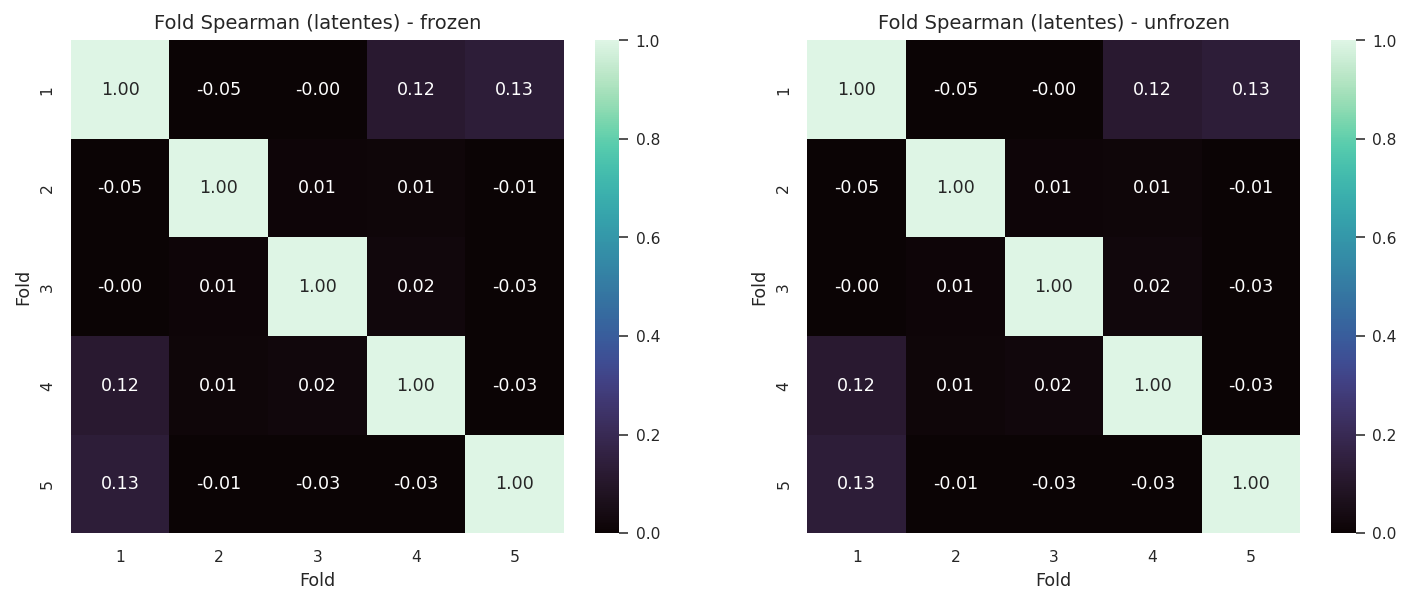

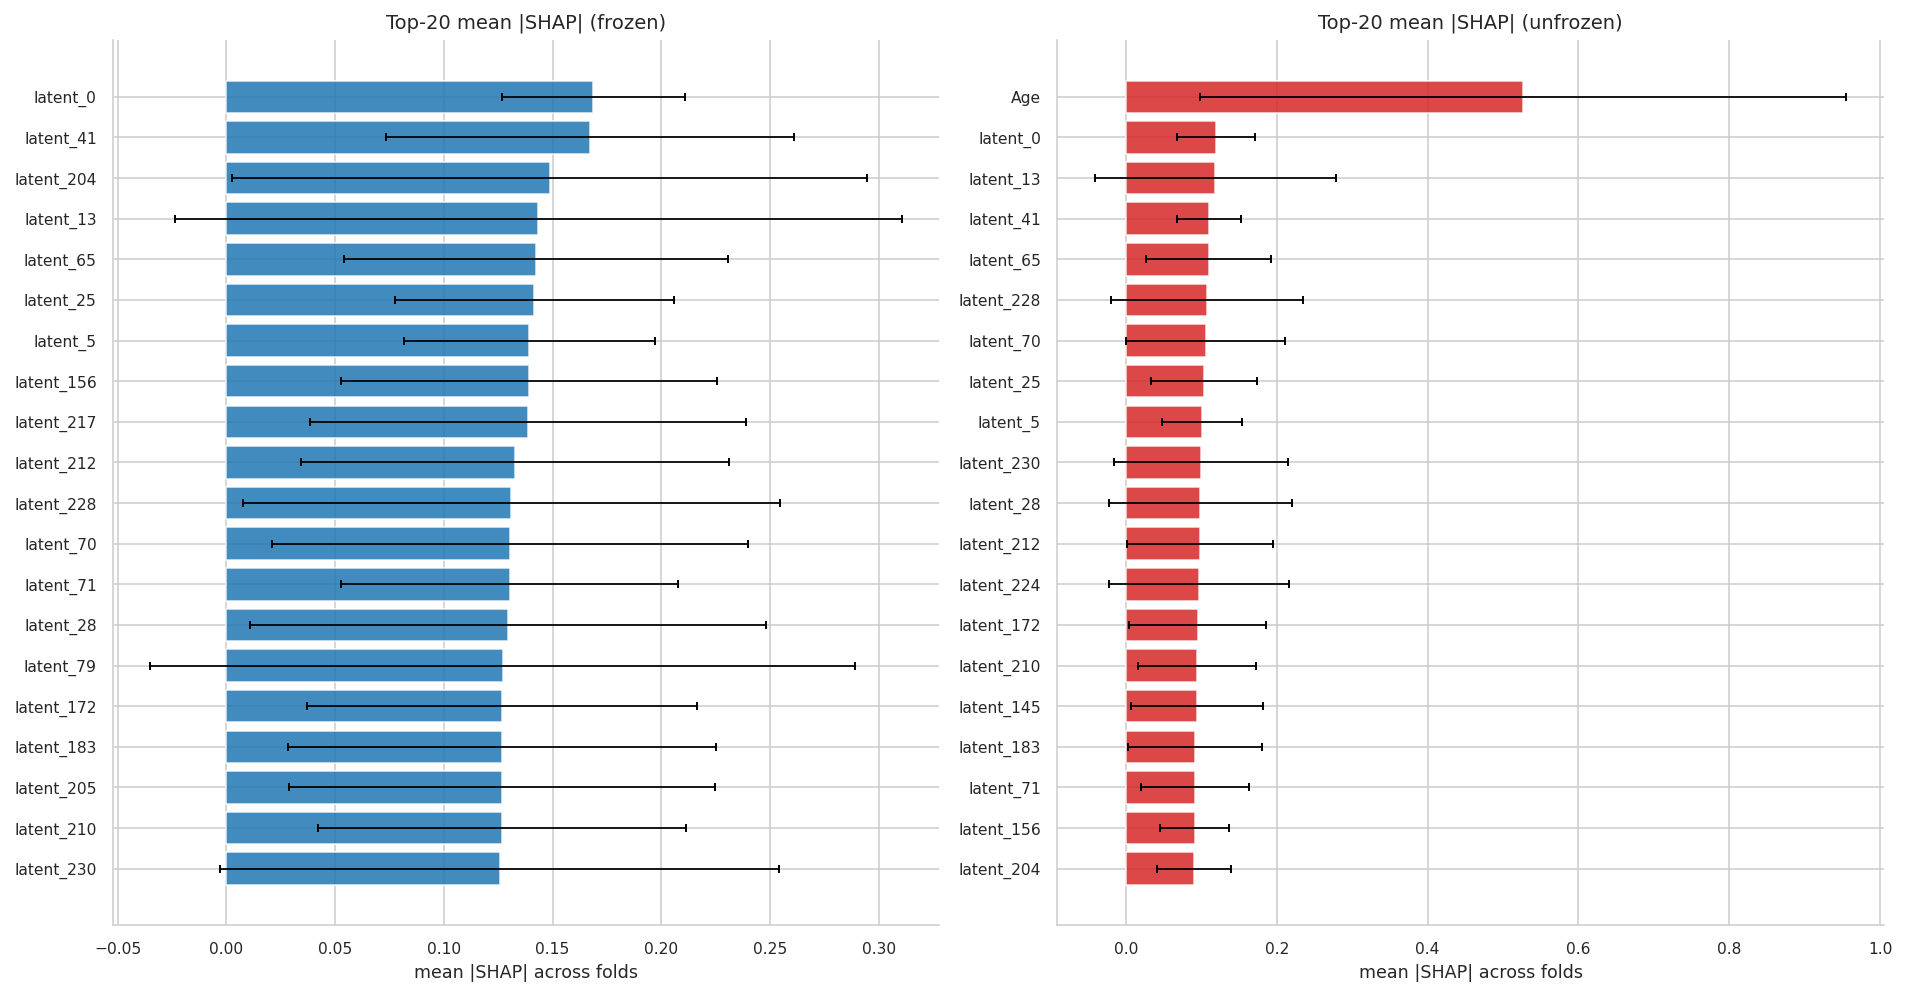

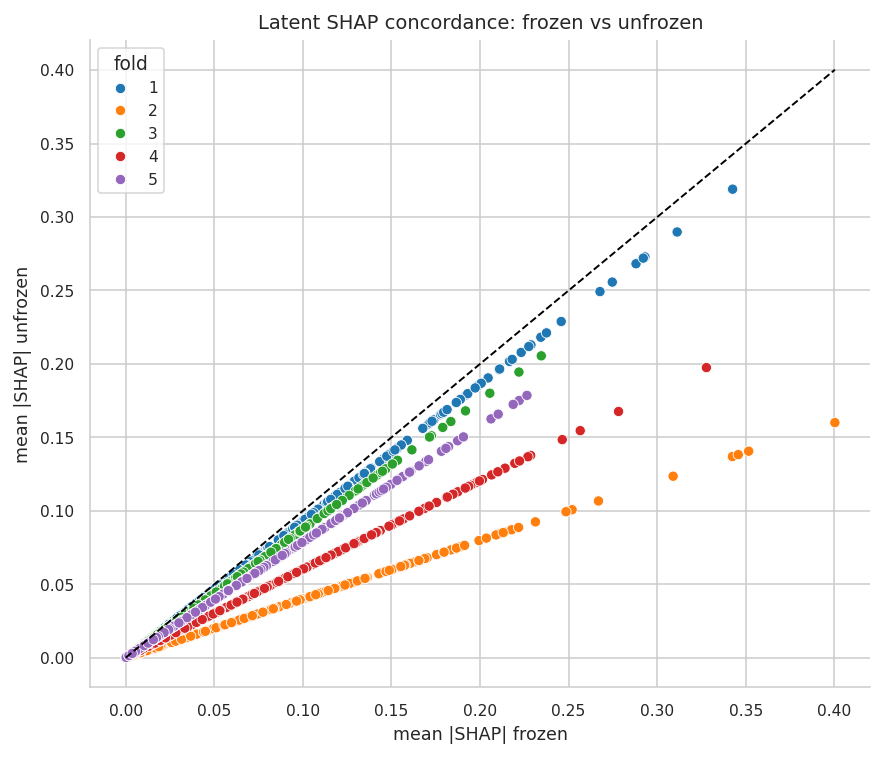

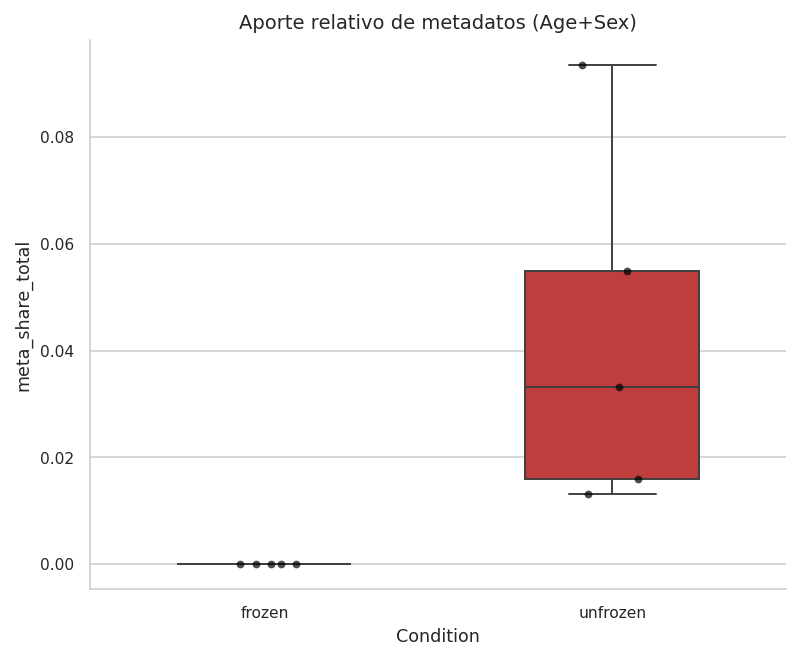

In [12]:
stability_rows = []
rho_by_tag = {}

for tag in [TAG_FROZEN, TAG_UNFROZEN]:
    lat = df_shap_fold[(df_shap_fold["tag"] == tag) & (df_shap_fold["group"] == "latent")].copy()
    pivot = lat.pivot(index="feature", columns="fold", values="mean_abs_shap").fillna(0.0)

    rho = pivot.corr(method="spearman")
    rho_by_tag[tag] = rho

    offdiag = rho.where(~np.eye(rho.shape[0], dtype=bool)).stack().to_numpy(dtype=float)
    offdiag = offdiag[np.isfinite(offdiag)]

    rank_matrix = pivot.rank(axis=0, ascending=False, method="average").T.to_numpy(dtype=float)
    W, chi2, p_kw = kendalls_w(rank_matrix)

    top_sets = [
        set(
            lat[(lat["fold"] == f) & (lat["rank"] <= TOPK_FEATURES)]["feature"].tolist()
        )
        for f in FOLDS
    ]
    j_mean, j_sd, j_n = mean_pairwise_jaccard(top_sets)

    stability_rows.append(
        {
            "tag": tag,
            "n_latent_features": int(pivot.shape[0]),
            "mean_pairwise_spearman": float(np.mean(offdiag)) if offdiag.size else np.nan,
            "std_pairwise_spearman": float(np.std(offdiag, ddof=1)) if offdiag.size > 1 else 0.0,
            "kendall_W": W,
            "kendall_chi2": chi2,
            "kendall_p": p_kw,
            "mean_top20_jaccard": j_mean,
            "std_top20_jaccard": j_sd,
            "n_jaccard_pairs": j_n,
        }
    )

df_shap_stability = pd.DataFrame(stability_rows)
df_shap_stability.to_csv(TBL_DIR / "shap_stability_metrics.csv", index=False)

rows_fvu = []
for fold in FOLDS:
    fz = df_shap_fold[
        (df_shap_fold["tag"] == TAG_FROZEN)
        & (df_shap_fold["fold"] == fold)
        & (df_shap_fold["group"] == "latent")
    ][["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "frozen"})

    uf = df_shap_fold[
        (df_shap_fold["tag"] == TAG_UNFROZEN)
        & (df_shap_fold["fold"] == fold)
        & (df_shap_fold["group"] == "latent")
    ][["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "unfrozen"})

    m = fz.merge(uf, on="feature", how="inner")
    if len(m) >= 3:
        pearson_r, pearson_p = stats.pearsonr(m["frozen"], m["unfrozen"])
        spearman_r, spearman_p = stats.spearmanr(m["frozen"], m["unfrozen"])
    else:
        pearson_r = pearson_p = spearman_r = spearman_p = np.nan

    rows_fvu.append(
        {
            "fold": fold,
            "n_latent_features": int(len(m)),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
        }
    )

df_frozen_vs_unfrozen = pd.DataFrame(rows_fvu)
df_frozen_vs_unfrozen.to_csv(TBL_DIR / "shap_frozen_vs_unfrozen_latent_concordance.csv", index=False)

meta_wide = df_meta_share.pivot(index="fold", columns="tag", values="meta_share_total")
if {TAG_FROZEN, TAG_UNFROZEN}.issubset(meta_wide.columns):
    w_stat, w_p = safe_wilcoxon(meta_wide[TAG_FROZEN].to_numpy(), meta_wide[TAG_UNFROZEN].to_numpy())
else:
    w_stat, w_p = np.nan, np.nan

print("SHAP stability summary:")
display(df_shap_stability)
print("\nFrozen vs Unfrozen concordance (latentes):")
display(df_frozen_vs_unfrozen)
print(f"\nWilcoxon meta_share_total (frozen vs unfrozen): stat={w_stat:.4g}, p={w_p:.4g}")

# ----------------------- FIGURA 1: estabilidad entre folds -----------------------
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
for ax, tag in zip(axes, [TAG_FROZEN, TAG_UNFROZEN]):
    rho = rho_by_tag[tag]
    sns.heatmap(
        rho,
        vmin=0,
        vmax=1,
        cmap="mako",
        square=True,
        cbar=True,
        annot=True,
        fmt=".2f",
        ax=ax,
    )
    ax.set_title(f"Fold Spearman (latentes) - {tag}")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Fold")
save_multi(fig, FIG_DIR / "fig_shap_fold_spearman")
plt.show()

# --------------------- FIGURA 2: top features por condicion ----------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 7.0), constrained_layout=True)
for ax, tag in zip(axes, [TAG_FROZEN, TAG_UNFROZEN]):
    d = (
        df_feature_summary[df_feature_summary["tag"] == tag]
        .sort_values("mean_abs_shap", ascending=False)
        .head(TOPK_FEATURES)
        .sort_values("mean_abs_shap", ascending=True)
        .reset_index(drop=True)
    )
    y = np.arange(len(d))
    ax.barh(y, d["mean_abs_shap"], color=COLORS[tag], alpha=0.85)
    err_low = np.clip(d["mean_abs_shap"] - d["ci95_low_t"], a_min=0, a_max=None)
    err_high = np.clip(d["ci95_high_t"] - d["mean_abs_shap"], a_min=0, a_max=None)
    ax.errorbar(
        d["mean_abs_shap"],
        y,
        xerr=np.vstack([err_low, err_high]),
        fmt="none",
        ecolor="black",
        lw=0.9,
        capsize=2,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(d["feature"])
    ax.set_title(f"Top-{TOPK_FEATURES} mean |SHAP| ({tag})")
    ax.set_xlabel("mean |SHAP| across folds")
save_multi(fig, FIG_DIR / "fig_shap_top_features_frozen_vs_unfrozen")
plt.show()

# ---------------- FIGURA 3: concordancia latent frozen vs unfrozen ---------------
scatter_rows = []
for fold in FOLDS:
    fz = df_shap_fold[
        (df_shap_fold["tag"] == TAG_FROZEN)
        & (df_shap_fold["fold"] == fold)
        & (df_shap_fold["group"] == "latent")
    ][["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "frozen"})
    uf = df_shap_fold[
        (df_shap_fold["tag"] == TAG_UNFROZEN)
        & (df_shap_fold["fold"] == fold)
        & (df_shap_fold["group"] == "latent")
    ][["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "unfrozen"})
    m = fz.merge(uf, on="feature", how="inner")
    m["fold"] = fold
    scatter_rows.append(m)

df_scatter = pd.concat(scatter_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(6.2, 5.3), constrained_layout=True)
sns.scatterplot(data=df_scatter, x="frozen", y="unfrozen", hue="fold", palette="tab10", s=28, ax=ax)
maxv = float(np.nanmax([df_scatter["frozen"].max(), df_scatter["unfrozen"].max()]))
ax.plot([0, maxv], [0, maxv], ls="--", lw=1.0, color="black")
ax.set_title("Latent SHAP concordance: frozen vs unfrozen")
ax.set_xlabel("mean |SHAP| frozen")
ax.set_ylabel("mean |SHAP| unfrozen")
save_multi(fig, FIG_DIR / "fig_shap_latent_concordance_frozen_vs_unfrozen")
plt.show()

# ------------------------- FIGURA 4: share metadatos (SIN WARNING) -----------------------------
fig, ax = plt.subplots(figsize=(5.6, 4.6), constrained_layout=True)
order = [TAG_FROZEN, TAG_UNFROZEN]

sns.boxplot(
    data=df_meta_share,
    x="tag",
    y="meta_share_total",
    order=order,
    hue="tag",
    dodge=False,
    palette={TAG_FROZEN: COLORS[TAG_FROZEN], TAG_UNFROZEN: COLORS[TAG_UNFROZEN]},
    width=0.5,
    ax=ax,
)
sns.stripplot(
    data=df_meta_share,
    x="tag",
    y="meta_share_total",
    order=order,
    color="black",
    size=4,
    alpha=0.7,
    ax=ax,
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_title("Aporte relativo de metadatos (Age+Sex)")
ax.set_xlabel("Condition")
ax.set_ylabel("meta_share_total")
save_multi(fig, FIG_DIR / "fig_shap_metadata_share")
plt.show()



,tag,K,obs_mean_jaccard,obs_sd_jaccard,null_mean_jaccard,null_p_ge_obs_mean
0,frozen,5,0.011111,0.035136,0.011042,0.09430
1,frozen,10,0.010526,0.022191,0.020868,0.33585
2,frozen,20,0.045985,0.043429,0.041391,0.47055
3,frozen,50,0.115820,0.034502,0.109277,0.38000
4,frozen,100,0.250487,0.042081,0.243417,0.35260
5,unfrozen,5,0.012500,0.039528,0.011042,0.09430
6,unfrozen,10,0.011111,0.023424,0.020868,0.33585
7,unfrozen,20,0.045601,0.044230,0.041391,0.47055
8,unfrozen,50,0.114556,0.033211,0.109277,0.38000
9,unfrozen,100,0.248137,0.042444,0.243417,0.45180


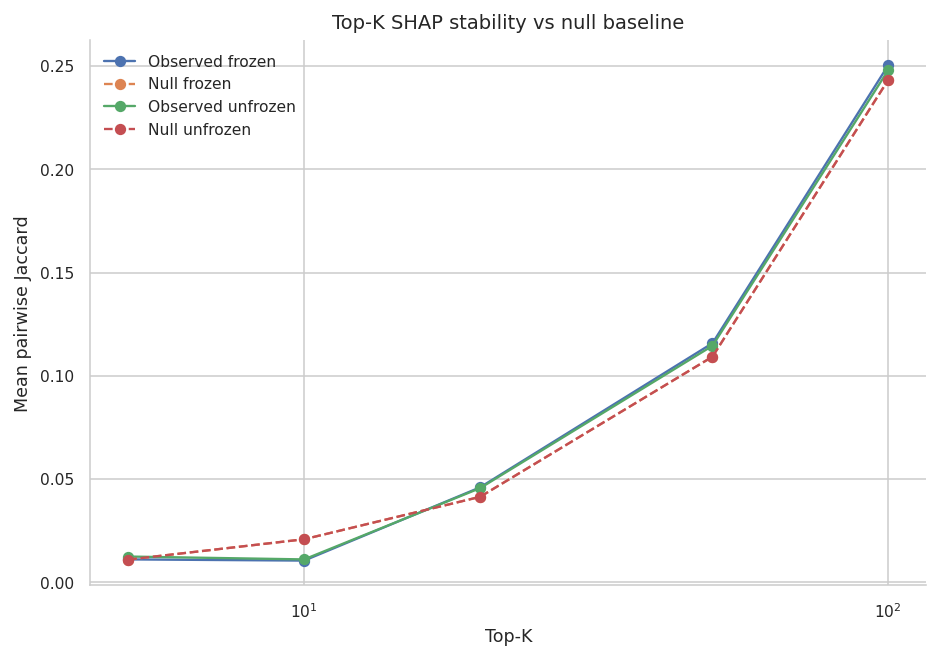

In [13]:
# =================== CELDA — SHAP STABILITY: BASELINE NULO + SWEEP K ===================
import numpy as np
import pandas as pd

def jaccard(a: set, b: set) -> float:
    u = len(a | b)
    return (len(a & b) / u) if u else np.nan

def topk_sets(df_lat, tag, k):
    sets = []
    for f in FOLDS:
        ss = set(df_lat[(df_lat["tag"] == tag) & (df_lat["fold"] == f) & (df_lat["rank"] <= k)]["feature"].tolist())
        sets.append(ss)
    return sets

# --- Baseline nulo por Monte Carlo (sets aleatorios) ---
def mc_jaccard_null(n_features: int, k: int, n_mc: int = 20000, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    vals = np.empty(n_mc, dtype=float)
    for i in range(n_mc):
        a = set(rng.choice(n_features, size=k, replace=False).tolist())
        b = set(rng.choice(n_features, size=k, replace=False).tolist())
        vals[i] = jaccard(a, b)
    return vals

df_lat = df_shap_fold[df_shap_fold["group"] == "latent"].copy()
n_features = df_lat["feature"].nunique()

Ks = [5, 10, 20, 50, 100]
rows = []

for tag in [TAG_FROZEN, TAG_UNFROZEN]:
    for k in Ks:
        sets = topk_sets(df_lat, tag, k)
        obs_vals = []
        for i in range(len(FOLDS)):
            for j in range(i+1, len(FOLDS)):
                obs_vals.append(jaccard(sets[i], sets[j]))
        obs_vals = np.asarray(obs_vals, float)

        null_vals = mc_jaccard_null(n_features=n_features, k=k, n_mc=20000, seed=SEED + k)
        p_ge = float((null_vals >= np.nanmean(obs_vals)).mean())

        rows.append({
            "tag": tag,
            "K": k,
            "obs_mean_jaccard": float(np.nanmean(obs_vals)),
            "obs_sd_jaccard": float(np.nanstd(obs_vals, ddof=1) if np.isfinite(obs_vals).sum() > 1 else 0.0),
            "null_mean_jaccard": float(np.nanmean(null_vals)),
            "null_p_ge_obs_mean": p_ge,
        })

df_jacc = pd.DataFrame(rows)
df_jacc.to_csv(TBL_DIR / "shap_topk_jaccard_vs_null.csv", index=False)
display(df_jacc)

# Figura: obs vs null mean(jaccard) por K
fig, ax = plt.subplots(figsize=(6.6, 4.6), constrained_layout=True)
for tag in [TAG_FROZEN, TAG_UNFROZEN]:
    dd = df_jacc[df_jacc["tag"] == tag].sort_values("K")
    ax.plot(dd["K"], dd["obs_mean_jaccard"], marker="o", lw=1.2, label=f"Observed {tag}")
    ax.plot(dd["K"], dd["null_mean_jaccard"], marker="o", lw=1.2, linestyle="--", label=f"Null {tag}")
ax.set_xscale("log")
ax.set_xlabel("Top-K")
ax.set_ylabel("Mean pairwise Jaccard")
ax.set_title("Top-K SHAP stability vs null baseline")
ax.legend(frameon=False)
save_multi(fig, FIG_DIR / "fig_shap_topk_jaccard_vs_null")
plt.show()


### §5.2 — Consenso de edges (saliency/IG)

**Definición de consenso** (todos los criterios aplicados simultáneamente):
- π ≥ 0.60: recurrencia inter-fold
- τ ≥ 0.60: consistencia de signo
- q ≤ 0.10: FDR-BH sobre p-valor binomial contra null

**Null distribution:** probabilidad combinatoria de seleccionar el edge aleatoriamente en top-K.


Resumen edge consensus:


,n_folds,n_edges_total,n_edges_topk_union,topk_per_fold,p_null,cons_pi,cons_tau,cons_q,n_edges_consensus
0,5,8515,1026,250,0.02936,0.6,0.6,0.1,10



Top edges por stability_mag:


,edge_key,freq,pi,mean_abs_topk,mean_signed_topk,tau,signedness,p_recurrence,q_recurrence,stability_mag,w_signed,src_AAL3_Name,dst_AAL3_Name,src_Refined_Network,dst_Refined_Network,src_Yeo17_Network,dst_Yeo17_Network
984,"(Temporal_Inf_R, Temporal_Mid_L)",3,0.6,0.000196,-0.000173,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Temporal_Inf_R,Temporal_Mid_L,Limbic_A_TempPole,DefaultMode_VentralMedial,Limbic_A_TempPole,DefaultMode_VentralMedial
985,"(Temporal_Inf_R, Temporal_Mid_R)",3,0.6,0.000169,-0.000145,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Temporal_Inf_R,Temporal_Mid_R,Limbic_A_TempPole,DefaultMode_VentralMedial,Limbic_A_TempPole,DefaultMode_VentralMedial
561,"(Frontal_Mid_2_L, Frontal_Sup_2_R)",3,0.6,0.000157,0.000155,1.0,1.0,0.000242,0.007761,0.6,0.6,Frontal_Mid_2_L,Frontal_Sup_2_R,Control_A,Control_B,Control_A,Control_B
462,"(Cingulate_Post_L, Precuneus_R)",3,0.6,0.000141,0.000077,1.0,1.0,0.000242,0.007761,0.6,0.6,Cingulate_Post_L,Precuneus_R,DefaultMode_Core,DefaultMode_DorsalMedial,DefaultMode_Core,DefaultMode_DorsalMedial
25,"(ACC_pre_R, Frontal_Med_Orb_R)",3,0.6,0.000135,-0.000105,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Frontal_Med_Orb_R,ACC_pre_R,Limbic_B_OFC,DefaultMode_VentralMedial,Limbic_B_OFC,DefaultMode_VentralMedial
511,"(Frontal_Inf_Orb_2_L, OFClat_R)",3,0.6,0.000131,-0.000082,1.0,-1.0,0.000242,0.007761,0.6,-0.6,OFClat_R,Frontal_Inf_Orb_2_L,Limbic_B_OFC,Background/NonCortical,Limbic_B_OFC,Background/NonCortical
484,"(Cingulate_Post_R, Thal_VL_L)",3,0.6,0.000119,0.000100,1.0,1.0,0.000242,0.007761,0.6,0.6,Cingulate_Post_R,Thal_VL_L,DefaultMode_Core,Background/NonCortical,DefaultMode_Core,Background/NonCortical
195,"(Cerebelum_10_L, Cerebelum_9_R)",3,0.6,0.000117,-0.000087,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Cerebelum_10_L,Cerebelum_9_R,Background/NonCortical,Background/NonCortical,Background/NonCortical,Background/NonCortical
595,"(Frontal_Sup_2_R, OFCant_R)",3,0.6,0.000115,0.000053,1.0,1.0,0.000242,0.007761,0.6,0.6,OFCant_R,Frontal_Sup_2_R,Limbic_B_OFC,Control_B,Limbic_B_OFC,Control_B
882,"(Parietal_Sup_R, Precuneus_L)",3,0.6,0.000097,0.000063,1.0,1.0,0.000242,0.007761,0.6,0.6,Parietal_Sup_R,Precuneus_L,DorsalAttention_A,DefaultMode_DorsalMedial,DorsalAttention_A,DefaultMode_DorsalMedial



Consensus set final:


,edge_key,freq,pi,mean_abs_topk,mean_signed_topk,tau,signedness,p_recurrence,q_recurrence,stability_mag,w_signed,src_AAL3_Name,dst_AAL3_Name,src_Refined_Network,dst_Refined_Network,src_Yeo17_Network,dst_Yeo17_Network
984,"(Temporal_Inf_R, Temporal_Mid_L)",3,0.6,0.000196,-0.000173,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Temporal_Inf_R,Temporal_Mid_L,Limbic_A_TempPole,DefaultMode_VentralMedial,Limbic_A_TempPole,DefaultMode_VentralMedial
985,"(Temporal_Inf_R, Temporal_Mid_R)",3,0.6,0.000169,-0.000145,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Temporal_Inf_R,Temporal_Mid_R,Limbic_A_TempPole,DefaultMode_VentralMedial,Limbic_A_TempPole,DefaultMode_VentralMedial
561,"(Frontal_Mid_2_L, Frontal_Sup_2_R)",3,0.6,0.000157,0.000155,1.0,1.0,0.000242,0.007761,0.6,0.6,Frontal_Mid_2_L,Frontal_Sup_2_R,Control_A,Control_B,Control_A,Control_B
462,"(Cingulate_Post_L, Precuneus_R)",3,0.6,0.000141,0.000077,1.0,1.0,0.000242,0.007761,0.6,0.6,Cingulate_Post_L,Precuneus_R,DefaultMode_Core,DefaultMode_DorsalMedial,DefaultMode_Core,DefaultMode_DorsalMedial
25,"(ACC_pre_R, Frontal_Med_Orb_R)",3,0.6,0.000135,-0.000105,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Frontal_Med_Orb_R,ACC_pre_R,Limbic_B_OFC,DefaultMode_VentralMedial,Limbic_B_OFC,DefaultMode_VentralMedial
511,"(Frontal_Inf_Orb_2_L, OFClat_R)",3,0.6,0.000131,-0.000082,1.0,-1.0,0.000242,0.007761,0.6,-0.6,OFClat_R,Frontal_Inf_Orb_2_L,Limbic_B_OFC,Background/NonCortical,Limbic_B_OFC,Background/NonCortical
484,"(Cingulate_Post_R, Thal_VL_L)",3,0.6,0.000119,0.000100,1.0,1.0,0.000242,0.007761,0.6,0.6,Cingulate_Post_R,Thal_VL_L,DefaultMode_Core,Background/NonCortical,DefaultMode_Core,Background/NonCortical
195,"(Cerebelum_10_L, Cerebelum_9_R)",3,0.6,0.000117,-0.000087,1.0,-1.0,0.000242,0.007761,0.6,-0.6,Cerebelum_10_L,Cerebelum_9_R,Background/NonCortical,Background/NonCortical,Background/NonCortical,Background/NonCortical
595,"(Frontal_Sup_2_R, OFCant_R)",3,0.6,0.000115,0.000053,1.0,1.0,0.000242,0.007761,0.6,0.6,OFCant_R,Frontal_Sup_2_R,Limbic_B_OFC,Control_B,Limbic_B_OFC,Control_B
882,"(Parietal_Sup_R, Precuneus_L)",3,0.6,0.000097,0.000063,1.0,1.0,0.000242,0.007761,0.6,0.6,Parietal_Sup_R,Precuneus_L,DorsalAttention_A,DefaultMode_DorsalMedial,DorsalAttention_A,DefaultMode_DorsalMedial


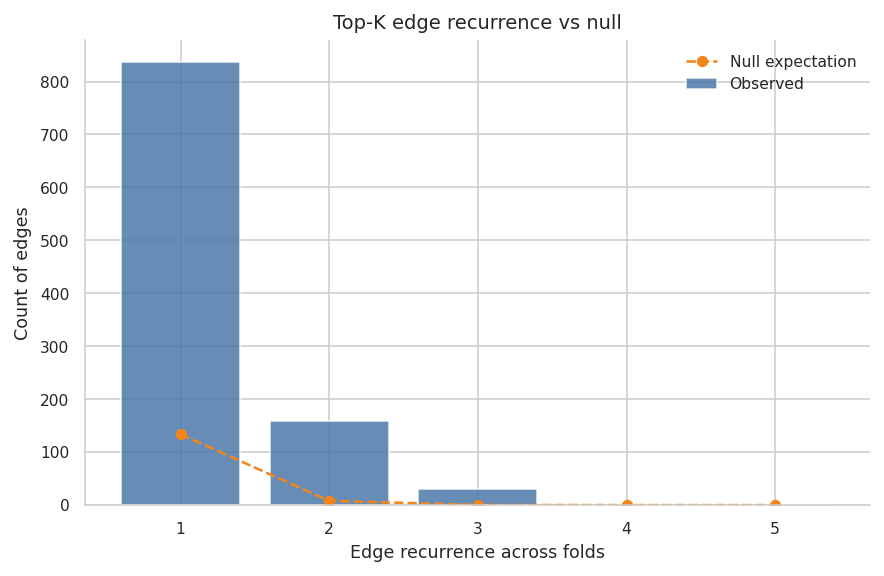

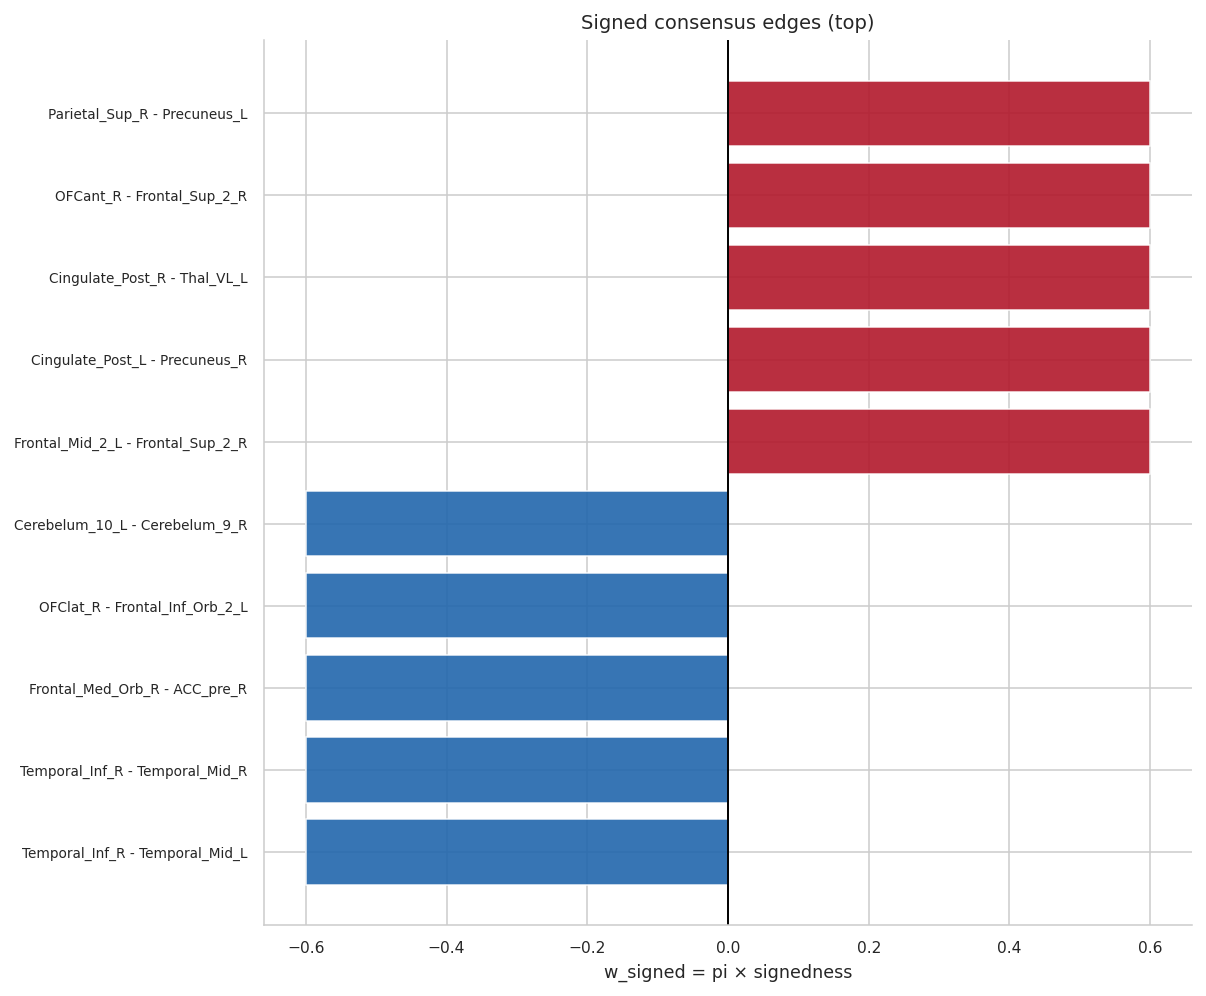

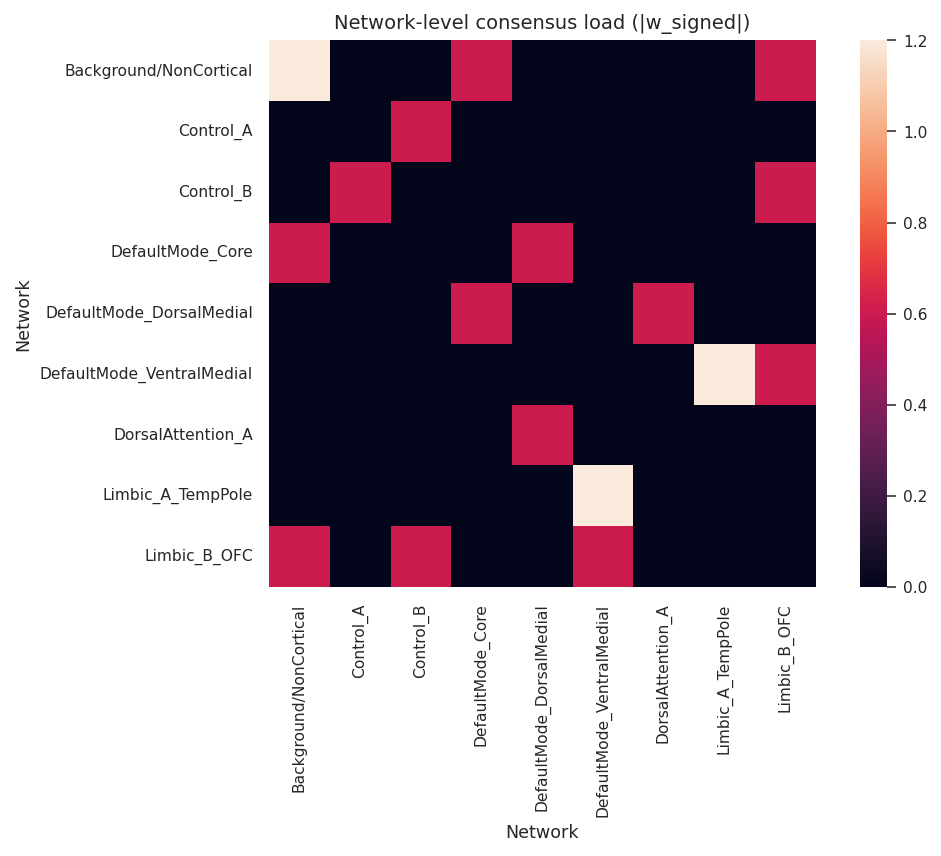

In [14]:
# ── §5.2 usa EDGE_TOPK_STABILITY, CONS_PI, CONS_TAU, CONS_Q de §1 ────────────

edge_rows = []
for fold in FOLDS:
    p = RUN_DIR / f"fold_{fold}" / f"interpretability_{CLF}" / f"ranking_conexiones_ANOTADO{SUFFIX}.csv"
    df = pd.read_csv(p)

    required_cols = {"Rank", "src_AAL3_Name", "dst_AAL3_Name", "Saliency_Signed", "Saliency_Abs"}
    miss = required_cols.difference(df.columns)
    if miss:
        raise ValueError(f"Fold {fold}: faltan columnas en ranking: {sorted(miss)}")

    df = df.copy()
    df["edge_key"] = [tuple(sorted((str(a), str(b)))) for a, b in zip(df["src_AAL3_Name"], df["dst_AAL3_Name"])]
    df["fold"] = fold
    df["in_topk"] = df["Rank"] <= EDGE_TOPK_STABILITY
    df["sign"] = np.sign(df["Saliency_Signed"].to_numpy(dtype=float)).astype(int)
    edge_rows.append(df)

df_edges = pd.concat(edge_rows, ignore_index=True)

edge_meta_cols = [
    c
    for c in [
        "src_AAL3_Name",
        "dst_AAL3_Name",
        "src_Refined_Network",
        "dst_Refined_Network",
        "src_Yeo17_Network",
        "dst_Yeo17_Network",
    ]
    if c in df_edges.columns
]
edge_meta = df_edges.sort_values("Rank").groupby("edge_key", as_index=False)[edge_meta_cols].first()

df_top = df_edges[df_edges["in_topk"]].copy()
if df_top.empty:
    raise RuntimeError("No hay edges en top-K. Revisa EDGE_TOPK_STABILITY o artefactos.")

freq = df_top.groupby("edge_key")["fold"].nunique().rename("freq")
pi = (freq / len(FOLDS)).rename("pi")
mean_abs = df_top.groupby("edge_key")["Saliency_Abs"].mean().rename("mean_abs_topk")
mean_signed = df_top.groupby("edge_key")["Saliency_Signed"].mean().rename("mean_signed_topk")
sign_stats = df_top.groupby("edge_key")["Saliency_Signed"].agg(
    tau=lambda s: float(np.abs(np.sign(np.asarray(s, dtype=float)).mean())),
    signedness=lambda s: float(np.sign(np.asarray(s, dtype=float)).mean()),
)

df_edge_consensus = pd.concat([freq, pi, mean_abs, mean_signed, sign_stats], axis=1).reset_index()

E_total = int(df_edges["edge_key"].nunique())
p_null = min(1.0, EDGE_TOPK_STABILITY / E_total)

df_edge_consensus["p_recurrence"] = stats.binom.sf(
    df_edge_consensus["freq"].to_numpy(dtype=int) - 1,
    len(FOLDS),
    p_null,
)
df_edge_consensus["q_recurrence"] = fdr_bh(df_edge_consensus["p_recurrence"].to_numpy(dtype=float))
df_edge_consensus["stability_mag"] = df_edge_consensus["pi"] * df_edge_consensus["tau"]
df_edge_consensus["w_signed"] = df_edge_consensus["pi"] * df_edge_consensus["signedness"]

df_edge_consensus = df_edge_consensus.merge(edge_meta, on="edge_key", how="left")
df_edge_consensus = df_edge_consensus.sort_values(["stability_mag", "mean_abs_topk"], ascending=[False, False])

if "src_AAL3_Name" not in df_edge_consensus.columns or "dst_AAL3_Name" not in df_edge_consensus.columns:
    df_edge_consensus[["src_AAL3_Name", "dst_AAL3_Name"]] = pd.DataFrame(
        df_edge_consensus["edge_key"].tolist(), index=df_edge_consensus.index
    )

consensus_set = df_edge_consensus.query(
    "pi >= @CONS_PI and tau >= @CONS_TAU and q_recurrence <= @CONS_Q"
).copy()

out_cons_main = RUN_DIR / f"consensus_edges_{CLF}_{SALIENCY_METHOD}_top{TOPK_LATENTS}.csv"
out_cons_tbl = TBL_DIR / f"consensus_edges_{CLF}_{SALIENCY_METHOD}_top{TOPK_LATENTS}.csv"
df_edge_consensus.to_csv(out_cons_main, index=False)
df_edge_consensus.to_csv(out_cons_tbl, index=False)
consensus_set.to_csv(TBL_DIR / f"consensus_set_{CLF}_{SALIENCY_METHOD}_top{TOPK_LATENTS}.csv", index=False)

edge_stats = pd.DataFrame(
    [
        {
            "n_folds": len(FOLDS),
            "n_edges_total": E_total,
            "n_edges_topk_union": int(len(df_edge_consensus)),
            "topk_per_fold": EDGE_TOPK_STABILITY,
            "p_null": p_null,
            "cons_pi": CONS_PI,
            "cons_tau": CONS_TAU,
            "cons_q": CONS_Q,
            "n_edges_consensus": int(len(consensus_set)),
        }
    ]
)
edge_stats.to_csv(TBL_DIR / "edge_consensus_summary_stats.csv", index=False)

print("Resumen edge consensus:")
display(edge_stats)
print("\nTop edges por stability_mag:")
display(df_edge_consensus.head(20))
print("\nConsensus set final:")
display(consensus_set.head(20))

# ─── FIGURA 5: recurrencia observada ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
obs = (
    df_edge_consensus["freq"].value_counts().reindex(range(1, len(FOLDS) + 1), fill_value=0)
)
x = np.array(obs.index, dtype=int)
ax.bar(x, obs.values, color="#4c78a8", alpha=0.85, label="Observed")
exp = len(df_edge_consensus) * stats.binom.pmf(x, len(FOLDS), p_null)
ax.plot(x, exp, "o--", color="#f58518", lw=1.3, label="Null expectation")
ax.set_xlabel("Edge recurrence across folds")
ax.set_ylabel("Count of edges")
ax.set_title("Top-K edge recurrence vs null")
ax.legend(frameon=False)
save_multi(fig, FIG_DIR / "fig_edge_recurrence_vs_null")
plt.show()

# ─── FIGURA 6: top edges signed consensus ────────────────────────────────────
plot_df = consensus_set.copy() if not consensus_set.empty else df_edge_consensus.head(25).copy()
plot_df = plot_df.head(25).copy()
plot_df["edge_label"] = plot_df["src_AAL3_Name"].astype(str) + " - " + plot_df["dst_AAL3_Name"].astype(str)
plot_df = plot_df.sort_values("w_signed", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 7.0), constrained_layout=True)
colors = np.where(plot_df["w_signed"] >= 0, COLORS["cons_pos"], COLORS["cons_neg"])
y = np.arange(len(plot_df))
ax.barh(y, plot_df["w_signed"], color=colors, alpha=0.9)
ax.axvline(0.0, color="black", lw=1.0)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["edge_label"], fontsize=7)
ax.set_xlabel("w_signed = pi × signedness")
ax.set_title("Signed consensus edges (top)")
save_multi(fig, FIG_DIR / "fig_edge_signed_consensus_top")
plt.show()

# ─── FIGURA 7: matriz por redes ──────────────────────────────────────────────
net_src = "src_Refined_Network" if "src_Refined_Network" in df_edge_consensus.columns else "src_Yeo17_Network"
net_dst = "dst_Refined_Network" if "dst_Refined_Network" in df_edge_consensus.columns else "dst_Yeo17_Network"

if net_src in df_edge_consensus.columns and net_dst in df_edge_consensus.columns:
    tmp = consensus_set.copy() if not consensus_set.empty else df_edge_consensus.head(300).copy()
    tmp = tmp.dropna(subset=[net_src, net_dst])
    nets = sorted(set(tmp[net_src].astype(str)) | set(tmp[net_dst].astype(str)))
    M = pd.DataFrame(0.0, index=nets, columns=nets)
    for _, r in tmp.iterrows():
        a = str(r[net_src])
        b = str(r[net_dst])
        w = abs(float(r["w_signed"]))
        M.loc[a, b] += w
        M.loc[b, a] += w
    fig, ax = plt.subplots(figsize=(7.2, 6.0), constrained_layout=True)
    sns.heatmap(M, cmap="rocket", square=True, ax=ax)
    ax.set_title("Network-level consensus load (|w_signed|)")
    ax.set_xlabel("Network")
    ax.set_ylabel("Network")
    save_multi(fig, FIG_DIR / "fig_edge_network_consensus_heatmap")
    plt.show()
else:
    print("No hay columnas de red disponibles para heatmap de redes.")


### §5.3 — Contribución por canal y contrastes estadísticos

Fracción de |ΔSal| por canal normalizada a la suma total.  
Tests: Friedman (repeated measures globales) + Wilcoxon pareado por par + corrección Holm.  
Effect size: Cohen's d pareado + Kendall's W como medida global.


Friedman channel test: stat=7.6, p=0.02237


,channel_name,channel_index_used,n_folds,mean_frac_abs,std_frac_abs,ci95_low_boot,ci95_high_boot
2,Ch2,2,5,0.363767,0.011346,0.354135,0.371006
0,Ch1,1,5,0.345951,0.022783,0.328604,0.363968
1,Ch0,0,5,0.290281,0.021857,0.272306,0.306513


,channel_a,channel_b,n_pairs,wilcoxon_stat,p_raw,p_holm
0,Ch0,Ch1,5,0.0,0.0625,0.1875
1,Ch0,Ch2,5,0.0,0.0625,0.1875
2,Ch1,Ch2,5,3.0,0.3125,0.3125


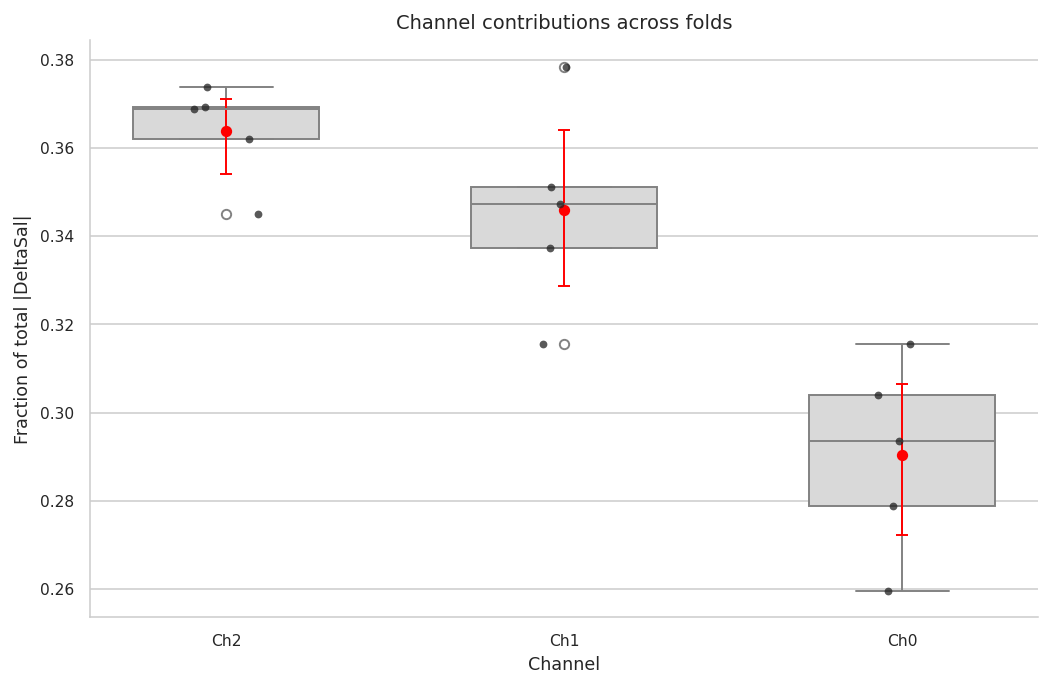

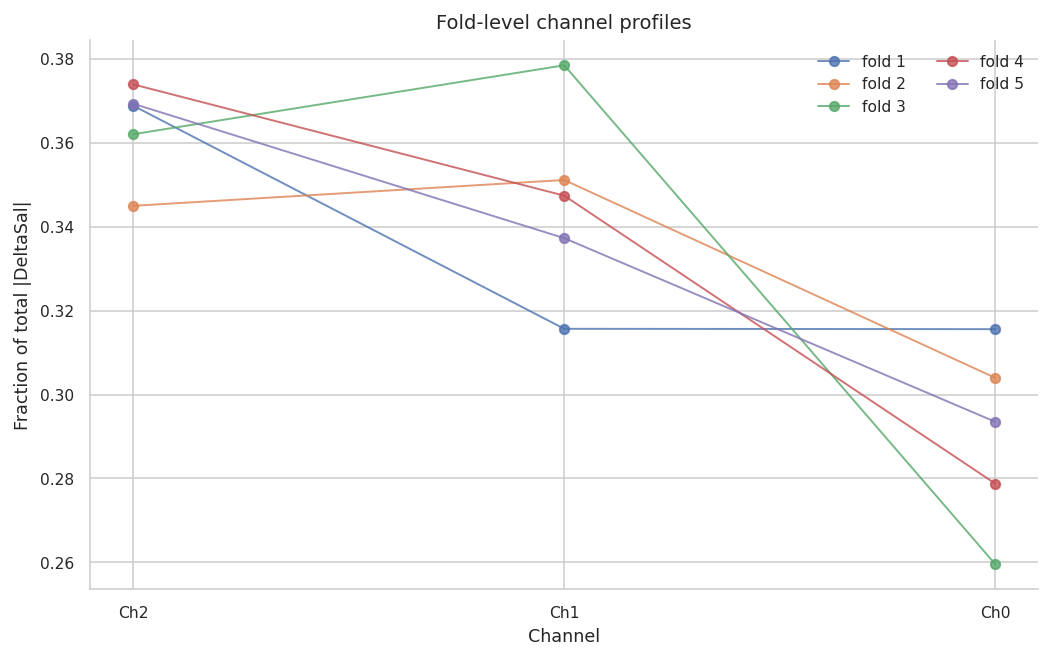

In [15]:
channel_rows = []
for fold in FOLDS:
    p = RUN_DIR / f"fold_{fold}" / f"interpretability_{CLF}" / f"channel_contributions{SUFFIX}.csv"
    df = pd.read_csv(p)
    req = {"channel_index_used", "channel_name", "l1_norm_fraction_abs"}
    miss = req.difference(df.columns)
    if miss:
        raise ValueError(f"Fold {fold}: faltan columnas en channel_contributions: {sorted(miss)}")
    df = df.copy()
    df["fold"] = fold
    channel_rows.append(df)

df_channel = pd.concat(channel_rows, ignore_index=True)
df_channel.to_csv(TBL_DIR / "channel_contributions_by_fold.csv", index=False)

sum_rows = []
for ch, g in df_channel.groupby("channel_name", sort=False):
    vals = g["l1_norm_fraction_abs"].to_numpy(dtype=float)
    mean_b, low_b, high_b = bootstrap_ci_mean(vals, n_boot=10000, alpha=0.05, seed=SEED)
    sum_rows.append(
        {
            "channel_name": ch,
            "channel_index_used": int(g["channel_index_used"].iloc[0]),
            "n_folds": int(g["fold"].nunique()),
            "mean_frac_abs": float(np.mean(vals)),
            "std_frac_abs": float(np.std(vals, ddof=1) if vals.size > 1 else 0.0),
            "ci95_low_boot": low_b,
            "ci95_high_boot": high_b,
        }
    )

df_channel_summary = pd.DataFrame(sum_rows).sort_values("mean_frac_abs", ascending=False)
df_channel_summary.to_csv(TBL_DIR / "channel_contributions_summary.csv", index=False)

df_ch_pivot = (
    df_channel.pivot_table(index="fold", columns="channel_name", values="l1_norm_fraction_abs", aggfunc="mean")
    .sort_index()
)

friedman_stat, friedman_p = np.nan, np.nan
if df_ch_pivot.shape[0] >= 3 and df_ch_pivot.shape[1] >= 3:
    cols = list(df_ch_pivot.columns)
    friedman_stat, friedman_p = stats.friedmanchisquare(*[df_ch_pivot[c].to_numpy(dtype=float) for c in cols])

pair_rows = []
for a, b in itertools.combinations(df_ch_pivot.columns.tolist(), 2):
    sub = df_ch_pivot[[a, b]].dropna()
    if len(sub) < 3:
        continue
    stat, p = safe_wilcoxon(sub[a].to_numpy(dtype=float), sub[b].to_numpy(dtype=float))
    pair_rows.append(
        {
            "channel_a": a,
            "channel_b": b,
            "n_pairs": int(len(sub)),
            "wilcoxon_stat": stat,
            "p_raw": p,
        }
    )

df_channel_pairs = pd.DataFrame(pair_rows)
if not df_channel_pairs.empty:
    df_channel_pairs["p_holm"] = holm_adjust(df_channel_pairs["p_raw"].to_numpy(dtype=float))
else:
    df_channel_pairs["p_holm"] = []

df_channel_pairs.to_csv(TBL_DIR / "channel_pairwise_wilcoxon_holm.csv", index=False)

print(f"Friedman channel test: stat={friedman_stat:.4g}, p={friedman_p:.4g}")
display(df_channel_summary)
display(df_channel_pairs)

# -------------------------- FIGURA 8: distribucion canal -------------------------
order = df_channel_summary["channel_name"].tolist()
fig, ax = plt.subplots(figsize=(7.4, 4.8), constrained_layout=True)
sns.boxplot(
    data=df_channel,
    x="channel_name",
    y="l1_norm_fraction_abs",
    order=order,
    color="#d9d9d9",
    width=0.55,
    ax=ax,
)
sns.stripplot(
    data=df_channel,
    x="channel_name",
    y="l1_norm_fraction_abs",
    order=order,
    color="#222222",
    size=4,
    alpha=0.75,
    ax=ax,
)
for i, ch in enumerate(order):
    row = df_channel_summary[df_channel_summary["channel_name"] == ch].iloc[0]
    m = float(row["mean_frac_abs"])
    lo = float(row["ci95_low_boot"])
    hi = float(row["ci95_high_boot"])
    ax.errorbar(i, m, yerr=[[m - lo], [hi - m]], fmt="o", color="red", capsize=3, lw=1.0)
ax.set_xlabel("Channel")
ax.set_ylabel("Fraction of total |DeltaSal|")
ax.set_title("Channel contributions across folds")
save_multi(fig, FIG_DIR / "fig_channel_contributions_distribution")
plt.show()

# ------------------------ FIGURA 9: perfiles fold por canal ----------------------
fig, ax = plt.subplots(figsize=(7.4, 4.6), constrained_layout=True)
for fold, g in df_channel.groupby("fold"):
    gg = g.set_index("channel_name").reindex(order)
    ax.plot(order, gg["l1_norm_fraction_abs"], marker="o", lw=1.0, alpha=0.8, label=f"fold {fold}")
ax.set_xlabel("Channel")
ax.set_ylabel("Fraction of total |DeltaSal|")
ax.set_title("Fold-level channel profiles")
ax.legend(frameon=False, ncol=2)
save_multi(fig, FIG_DIR / "fig_channel_contributions_fold_profiles")
plt.show()


In [16]:
# =================== CELDA — CHANNEL EFFECT SIZES (paired) ===================
import numpy as np
import pandas as pd

# Kendall's W a partir de Friedman (efecto global; interpretación: 0..1)
if np.isfinite(friedman_stat) and df_ch_pivot.shape[0] > 0 and df_ch_pivot.shape[1] > 1:
    n = df_ch_pivot.shape[0]   # folds
    k = df_ch_pivot.shape[1]   # canales
    W_eff = float(friedman_stat / (n * (k - 1)))
else:
    W_eff = np.nan

def paired_cohens_d(x, y):
    d = np.asarray(x) - np.asarray(y)
    sd = np.std(d, ddof=1) if len(d) > 1 else np.nan
    return float(np.mean(d) / sd) if sd and np.isfinite(sd) and sd > 0 else np.nan

eff_rows = []
cols = list(df_ch_pivot.columns)
for a, b in itertools.combinations(cols, 2):
    sub = df_ch_pivot[[a, b]].dropna()
    if len(sub) < 3:
        continue
    d = paired_cohens_d(sub[a].to_numpy(), sub[b].to_numpy())
    eff_rows.append({"channel_a": a, "channel_b": b, "n_pairs": int(len(sub)), "paired_cohens_d(a-b)": d})

df_eff = pd.DataFrame(eff_rows)
df_eff.to_csv(TBL_DIR / "channel_effect_sizes_paired_cohens_d.csv", index=False)

print(f"[CHANNEL] Kendall's W (global Friedman effect size) = {W_eff:.4f}")
display(df_eff.sort_values("paired_cohens_d(a-b)", ascending=False))


[CHANNEL] Kendall's W (global Friedman effect size) = 0.7600


,channel_a,channel_b,n_pairs,paired_cohens_d(a-b)
2,Ch1,Ch2,5,-0.622962
0,Ch0,Ch1,5,-1.289145
1,Ch0,Ch2,5,-2.789887


## §6 — Índice de outputs + Handoff

Genera `outputs_index.csv` (inventario de todos los artefactos bajo `OUTPUT_DIR`)  
y valida el handoff para `signature_figures_new.ipynb`.


In [17]:
# ─── §6.1  Validación de handoff ────────────────────────────────────────────
# Comprueba que ranking_conexiones_ANOTADO existe con columnas obligatorias.

required_rank_cols = {
    "Rank",
    "src_AAL3_Name",
    "dst_AAL3_Name",
    "idx_i",
    "idx_j",
    "Saliency_Signed",
}

handoff_rows = []
for fold in FOLDS:
    p = (
        RUN_DIR
        / f"fold_{fold}"
        / f"interpretability_{CLF}"
        / f"ranking_conexiones_ANOTADO{SUFFIX}.csv"
    )
    exists = p.exists()
    missing_cols: list[str] = []
    n_rows = float("nan")
    if exists:
        df_tmp = pd.read_csv(p)
        n_rows = int(len(df_tmp))
        missing_cols = sorted(required_rank_cols.difference(df_tmp.columns))
    handoff_rows.append(
        {
            "fold": fold,
            "ranking_path": str(p),
            "exists": exists,
            "n_rows": n_rows,
            "missing_required_cols": ",".join(missing_cols),
            "is_valid": bool(exists and not missing_cols),
        }
    )

df_handoff = pd.DataFrame(handoff_rows)
df_handoff.to_csv(TBL_DIR / "signature_handoff_validation.csv", index=False)
display(df_handoff.style.apply(
    lambda col: ["background-color:#d4edda" if v else "background-color:#f8d7da" for v in col],
    subset=["is_valid"],
))

if not df_handoff["is_valid"].all():
    raise RuntimeError(
        "Handoff incompleto para signature_figures_new.ipynb. "
        "Revisa los folds marcados como inválidos en la tabla anterior."
    )
print("Handoff válido en todos los folds.")

# ─── §6.2  Inventario de artefactos ──────────────────────────────────────────
# Walk completo sobre OUTPUT_DIR; clasifica por extensión.

EXT_BUCKET = {
    ".csv":    "tabla",
    ".json":   "json",
    ".joblib": "modelo",
    ".pt":     "modelo",
    ".npy":    "array",
    ".png":    "figura",
    ".pdf":    "figura",
    ".svg":    "figura",
    ".txt":    "log",
    ".html":   "log",
}

index_rows = []
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        bucket = EXT_BUCKET.get(path.suffix.lower(), "otro")
        size_kb = path.stat().st_size / 1024
        index_rows.append(
            {
                "bucket": bucket,
                "relative_path": str(path.relative_to(OUTPUT_DIR)),
                "size_kb": round(size_kb, 1),
                "mtime": datetime.fromtimestamp(path.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
            }
        )

df_index = pd.DataFrame(index_rows)
idx_path = OUTPUT_DIR / f"outputs_index_{CLF}.csv"
df_index.to_csv(idx_path, index=False)

print(f"\nArtefactos en OUTPUT_DIR ({OUTPUT_DIR.name}):")
print(df_index.groupby("bucket")[["size_kb"]].agg(count=("size_kb", "count"),
                                                   total_kb=("size_kb", "sum")).to_string())
print(f"\nÍndice completo → {idx_path}")

# ─── §6.3  Manifest final ─────────────────────────────────────────────────────
manifest = {
    "created_utc"      : datetime.now(timezone.utc).isoformat(),
    "results_dir"      : str(RESULTS_DIR),
    "output_dir"       : str(OUTPUT_DIR),
    "clf"              : CLF,
    "suffix"           : SUFFIX,
    "n_folds"          : len(FOLDS),
    "folds"            : FOLDS,
    "topk_latents"     : TOPK_LATENTS,
    "edge_topk_stability": EDGE_TOPK_STABILITY,
    "cons_pi"          : CONS_PI,
    "cons_tau"         : CONS_TAU,
    "cons_q"           : CONS_Q,
    "tables_dir"       : str(TBL_DIR),
    "figures_dir"      : str(FIG_DIR),
    "total_artifacts"  : len(df_index),
    "handoff_valid"    : bool(df_handoff["is_valid"].all()),
}
mf_path = OUTPUT_DIR / "analysis_manifest.json"
mf_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(f"Manifest → {mf_path}")
print("\nListo para continuar en notebooks/signature_figures_new.ipynb")


,fold,ranking_path,exists,n_rows,missing_required_cols,is_valid
0,1,/home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/fold_1/interpretability_logreg/ranking_conexiones_ANOTADO_integrated_gradients_top50.csv,True,8515,,True
1,2,/home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/fold_2/interpretability_logreg/ranking_conexiones_ANOTADO_integrated_gradients_top50.csv,True,8515,,True
2,3,/home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/fold_3/interpretability_logreg/ranking_conexiones_ANOTADO_integrated_gradients_top50.csv,True,8515,,True
3,4,/home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/fold_4/interpretability_logreg/ranking_conexiones_ANOTADO_integrated_gradients_top50.csv,True,8515,,True
4,5,/home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/fold_5/interpretability_logreg/ranking_conexiones_ANOTADO_integrated_gradients_top50.csv,True,8515,,True


Handoff válido en todos los folds.

Artefactos en OUTPUT_DIR (interpretability_paper_output):
        count  total_kb
bucket                 
figura     30    2687.4
json        2       2.5
tabla      17     466.5

Índice completo → /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/interpretability_paper_output/outputs_index_logreg.csv
Manifest → /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/interpretability_paper_output/analysis_manifest.json

Listo para continuar en notebooks/signature_figures_new.ipynb


## Checklist final de calidad

**§1 Configuración**
- [ ] `RESULTS_DIR` apunta al run correcto (`vae_3channels_beta65_pro`).
- [ ] `OUTPUT_DIR`, `FIG_DIR`, `TBL_DIR`, `LOG_DIR` creados automáticamente.

**§2 Entorno**
- [ ] Snapshot de versiones guardado en `LOG_DIR/env_snapshot.txt`.

**§3 Artefactos**
- [ ] `run_manifest.json` generado con RUN_TAG, tensor path, FOLDS detectados.
- [ ] Tabla de procedencia mostrada sin celdas vacías.

**§4 Ejecución**
- [ ] Pipeline de interpretabilidad completado en todos los folds sin errores.
- [ ] Integridad: `shap_pack`, ranking y channel_contributions presentes por fold.
- [ ] Rendimiento OOF (AUC-ROC) reportado y guardado.

**§5 Análisis**
- [ ] Importancia SHAP promediada por fold, guardada en TBL_DIR.
- [ ] Estabilidad SHAP: correlación de Spearman ρ reportada con IC 95 %.
- [ ] Baseline Jaccard nulo calculado vs. ranking de SHAP.
- [ ] Consenso de edges con FDR (BH) aplicado al umbral.
- [ ] Contribución por canal: Wilcoxon + Holm-Bonferroni + Cohen d.

**§6 Outputs**
- [ ] `signature_handoff_validation.csv` sin folds inválidos.
- [ ] `outputs_index_{CLF}.csv` generado (inventario completo).
- [ ] `analysis_manifest.json` escrito.
- [ ] Todos los outputs en `OUTPUT_DIR` (sin rutas hard-coded).


/home/diego/anaconda3/envs/vae_ad/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


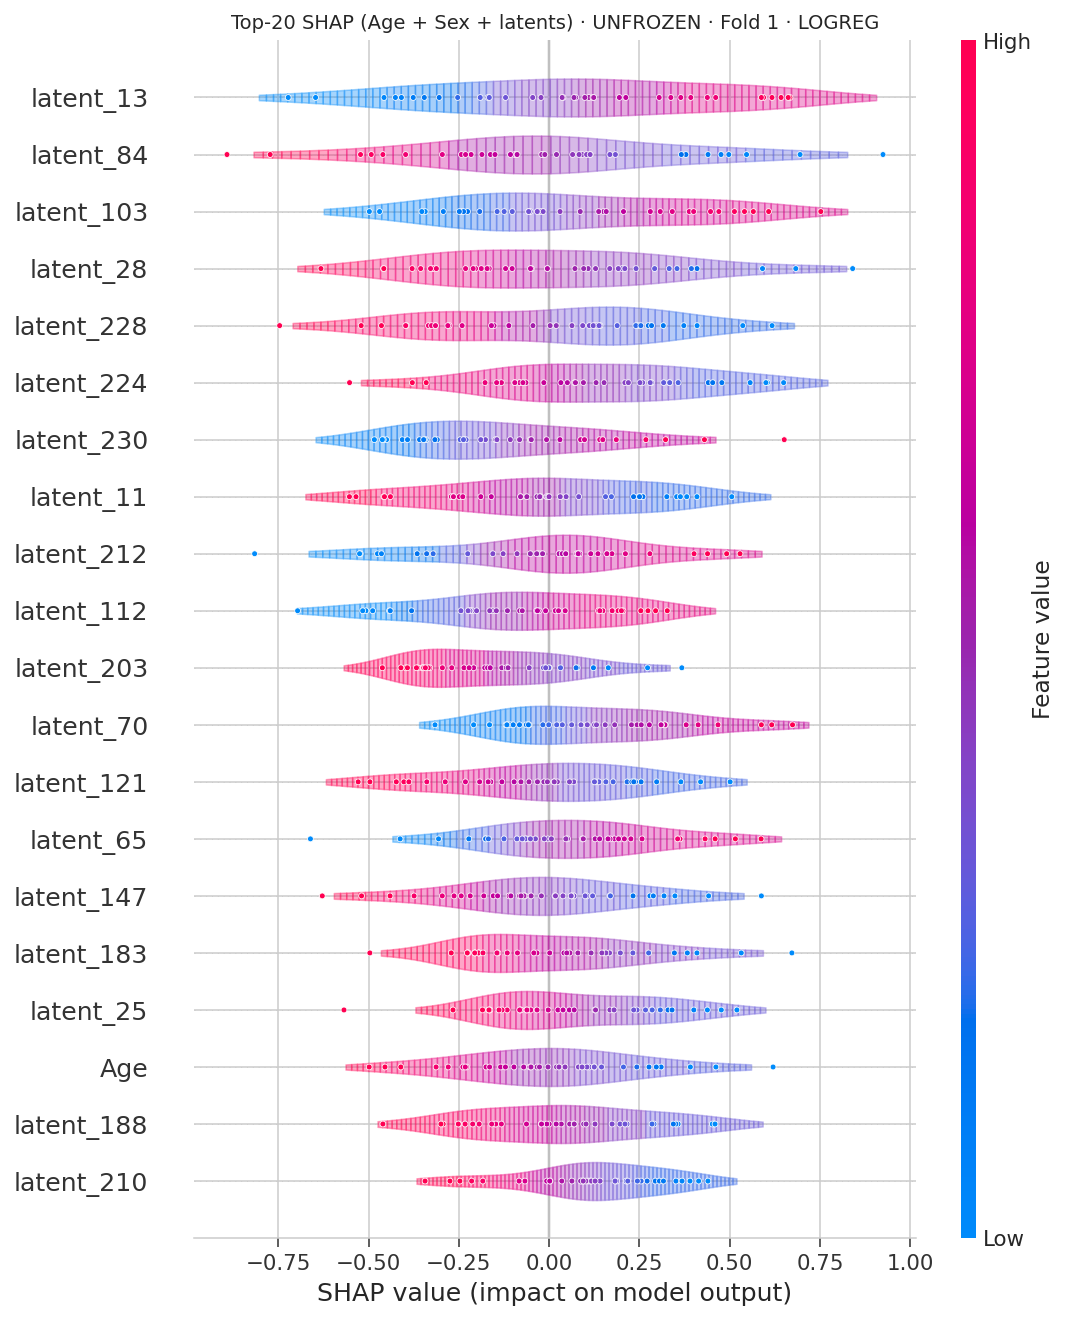

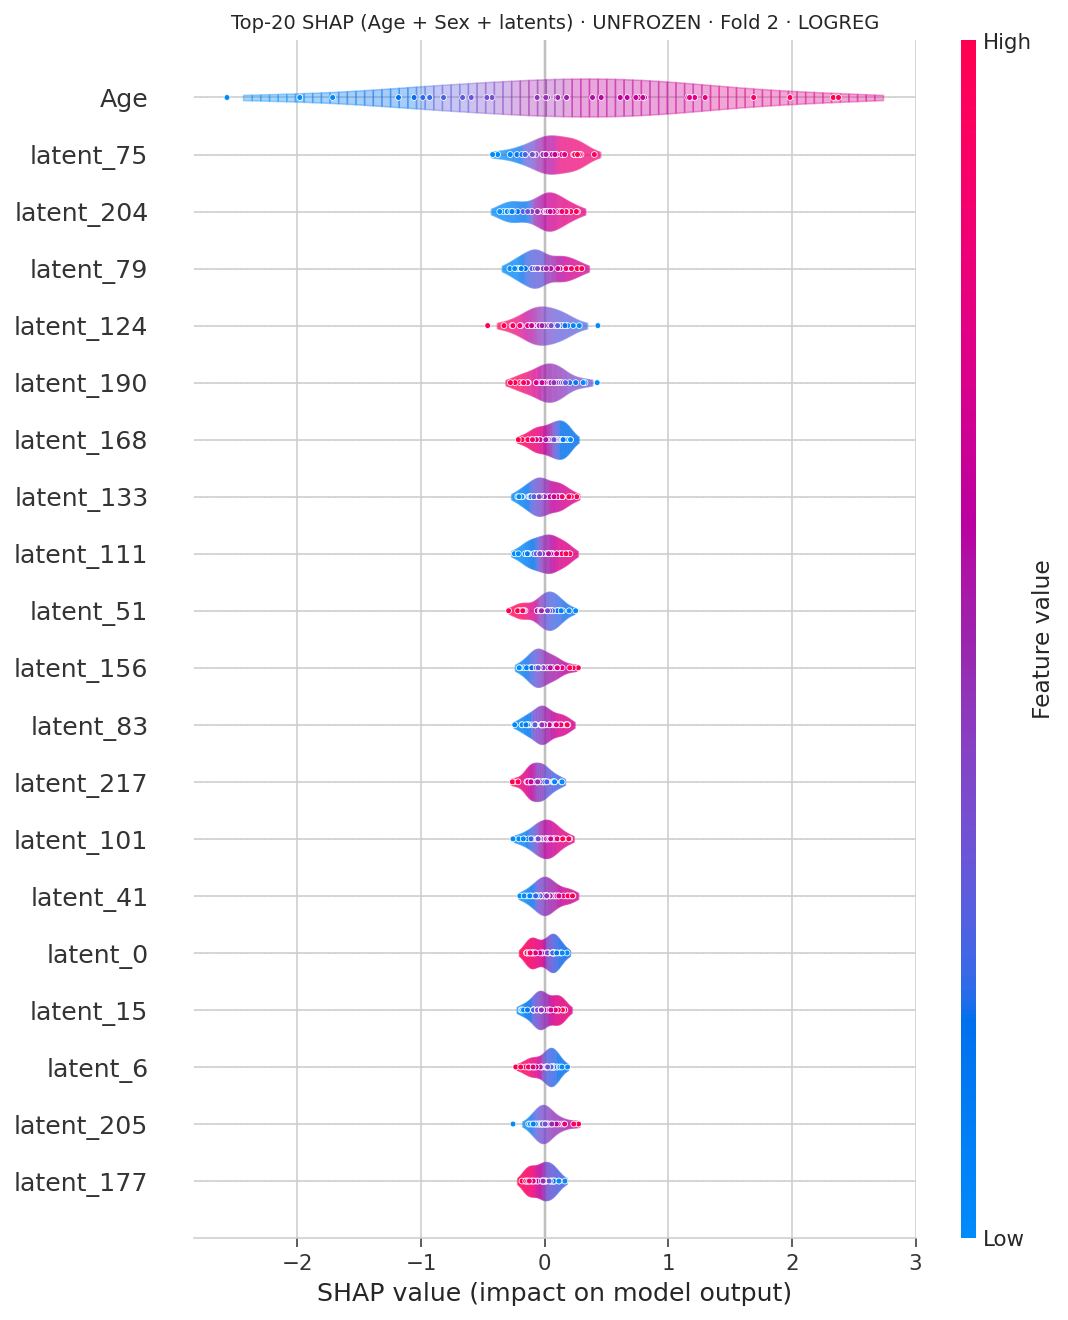

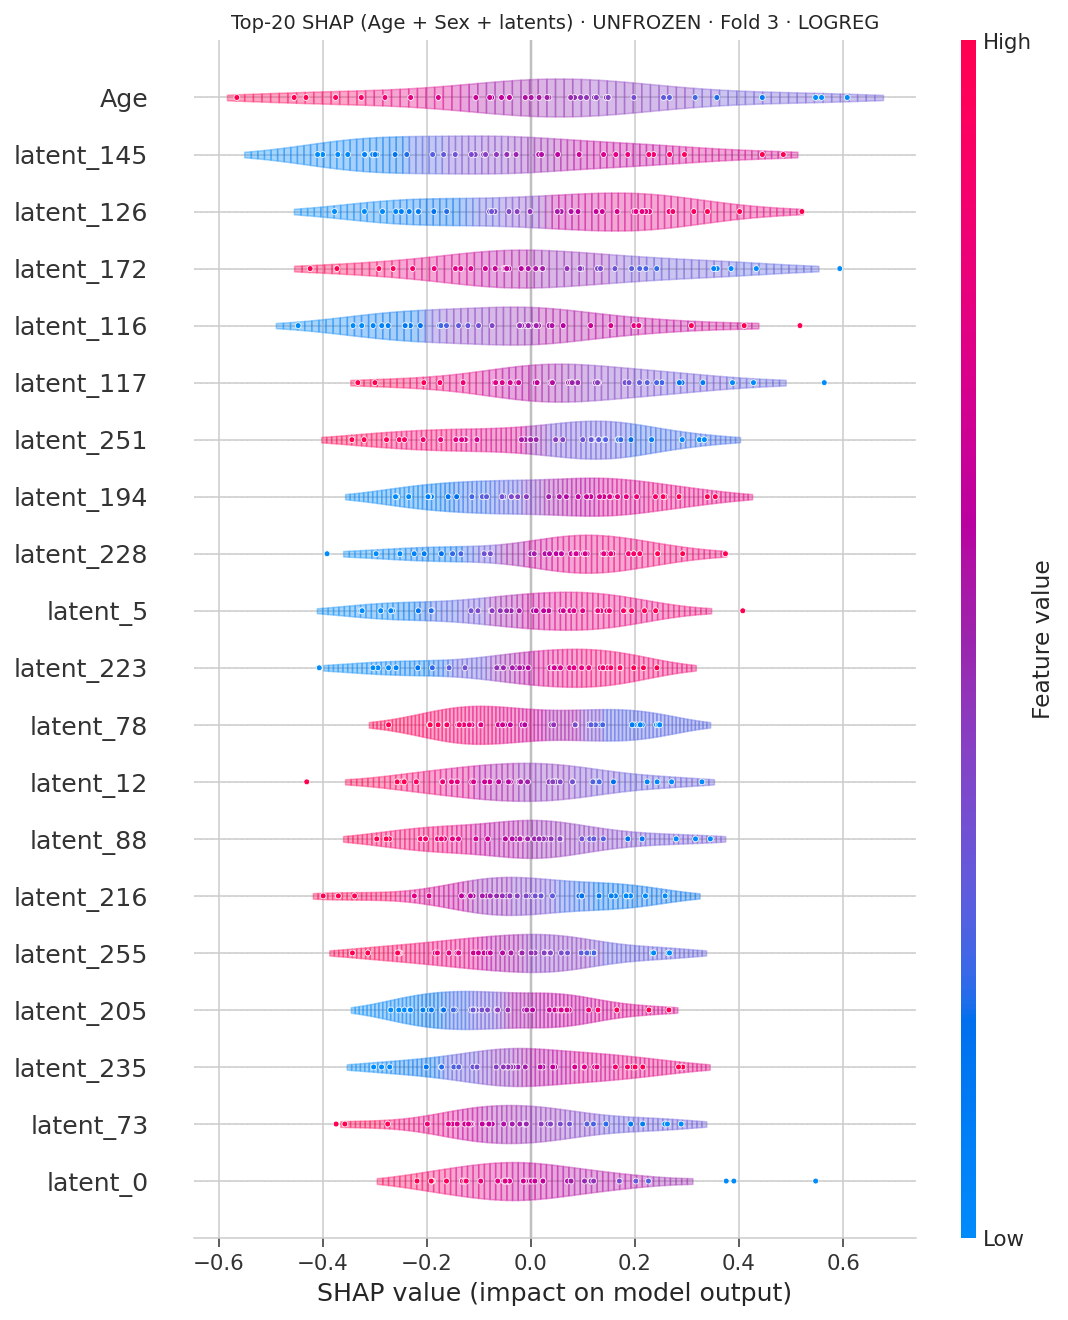

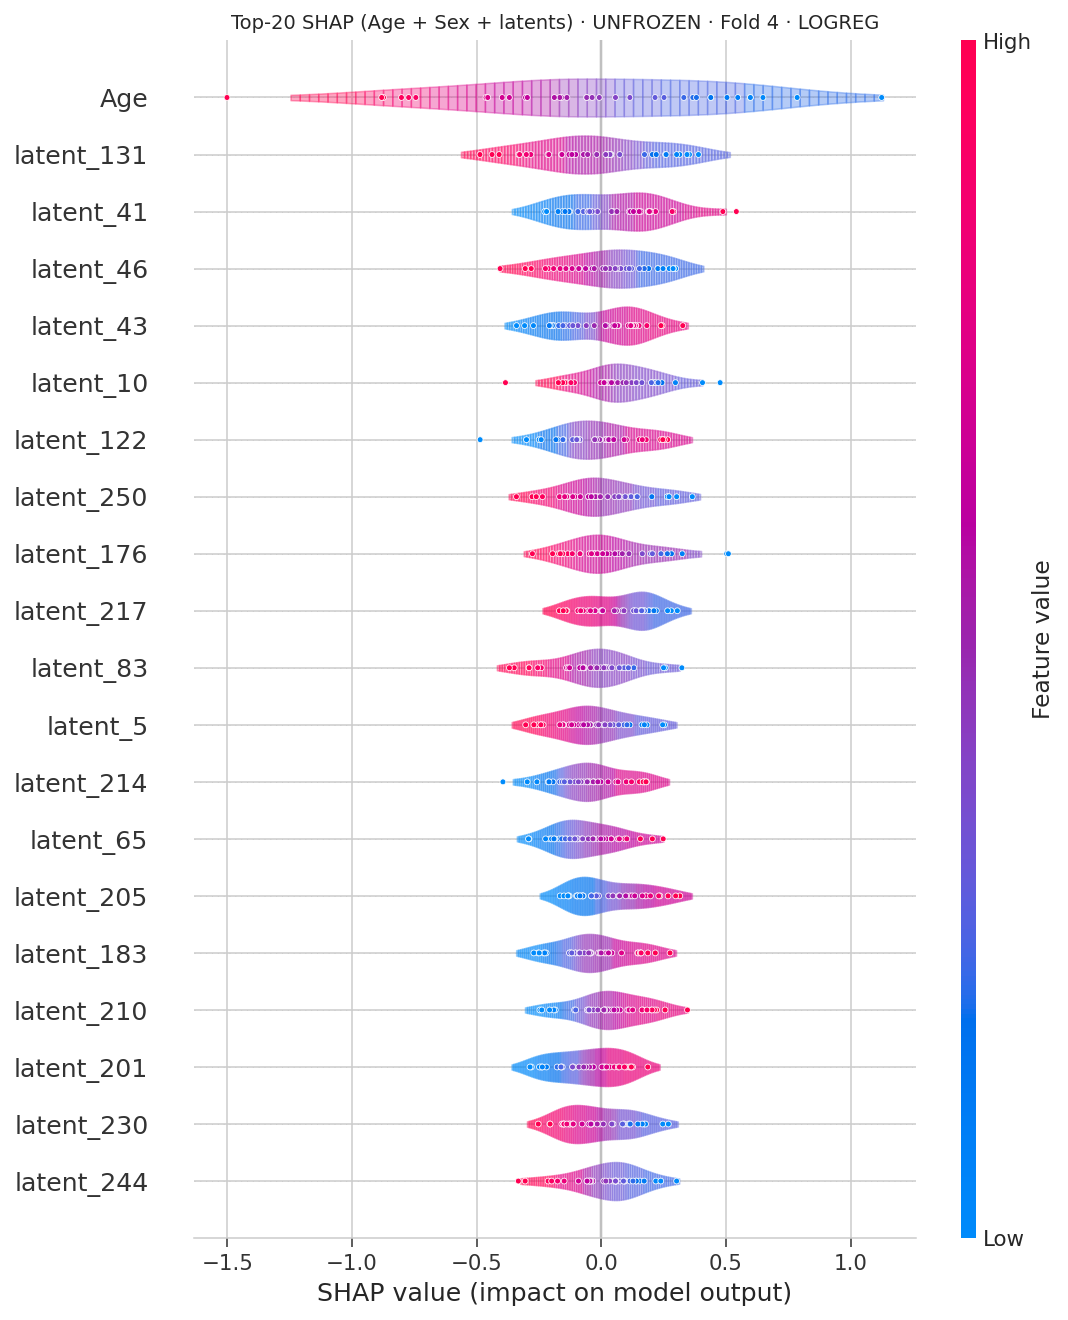

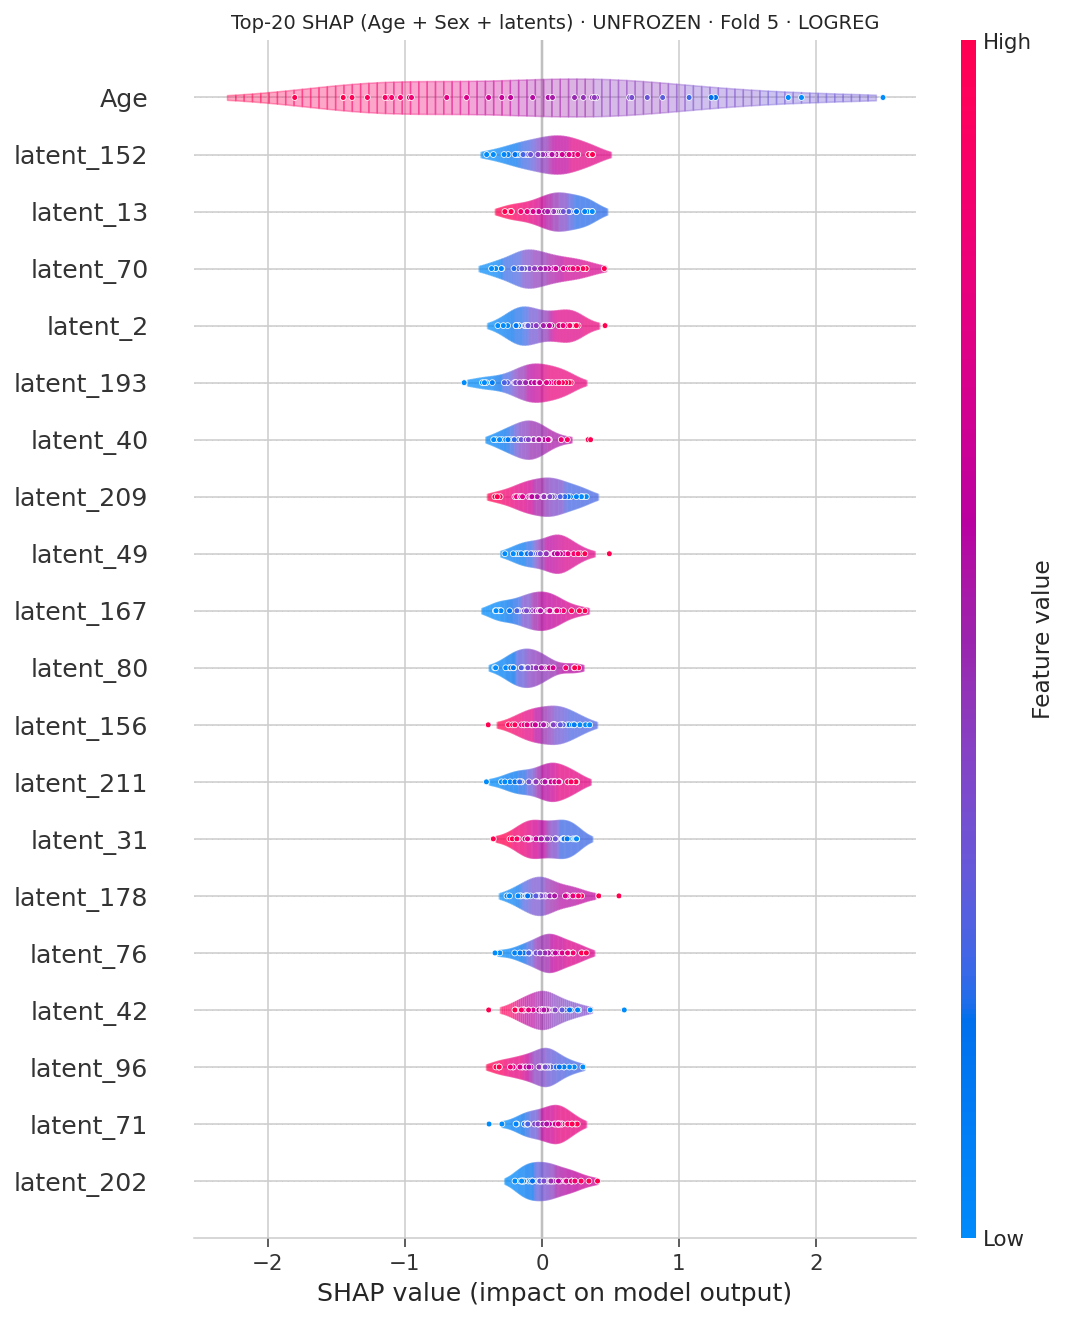

In [18]:
# =================== CELDA — SHAP UNFROZEN: Top-20 (Age + Sex + latents) por fold ===================
# (Corregida para usar funciones globales y firma correcta)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

# Ya contamos con las funciones globales:
#   - load_shap_pack(fold, tag)
#   - canonical_feature_name (similar a prettify_feature)
#   - save_multi(fig, out_base)
#   - RUN_DIR, CLF, FOLDS definidos globalmente

TOPK = 20
TAG  = "unfrozen"

# Helper local para ajustar opacidad (no está en global)
def ajustar_opacidad_violin(alpha: float = 0.35, subir_puntos: bool = True, ax=None):
    ax = ax or plt.gca()
    for pc in ax.findobj(mpl.collections.PolyCollection):
        pc.set_alpha(alpha)
    for p in ax.patches:
        try:
            p.set_alpha(alpha)
        except Exception:
            pass
    if subir_puntos:
        for sc in ax.findobj(mpl.collections.PathCollection):
            sc.set_zorder(3)
            sc.set_edgecolor("white")
            sc.set_linewidth(0.4)

# Aseguramos que X_test sea DataFrame numérico
def _ensure_df(X, featnames):
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(np.asarray(X), columns=list(map(str, featnames)))
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.Categorical(df[c]).codes.astype(float)
    return df

# Loop sobre folds
for f in FOLDS:
    try:
        pack = load_shap_pack(fold=f, tag=TAG)   # <-- CORREGIDO: solo fold y tag
    except FileNotFoundError as e:
        print(f"[WARN] Fold {f}: {e}")
        continue

    shap_vals = np.asarray(pack["shap_values"], float)   # (N, F)
    featnames = list(map(str, pack["feature_names"]))

    # X de test (procesado)
    Xtest = pack.get("X_test", pack.get("X_raw_test", None))
    if Xtest is None:
        raise KeyError(f"Fold {f}: el pack no trae 'X_test' ni 'X_raw_test'. Keys={list(pack.keys())}")

    Xtest = _ensure_df(Xtest, featnames)

    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:TOPK]

    S_top = shap_vals[:, order]
    X_top = Xtest.iloc[:, order]
    pretty = [canonical_feature_name(featnames[i]) for i in order]   # usar función global

    plt.figure(figsize=(8.2, 6.2))
    shap.summary_plot(
        S_top,
        X_top,
        feature_names=pretty,
        max_display=TOPK,
        plot_type="violin",
        show=False
    )
    ajustar_opacidad_violin(alpha=0.35, subir_puntos=True)

    plt.title(f"Top-{TOPK} SHAP (Age + Sex + latents) · UNFROZEN · Fold {f} · {CLF.upper()}")
    plt.tight_layout()

    out_base = RUN_DIR / f"fold_{f}" / "interpretability_shap" / f"fold{f}_shap_top{TOPK}_UNFROZEN_violin"
    out_base.parent.mkdir(parents=True, exist_ok=True)
    save_multi(plt.gcf(), out_base)   # <-- CORREGIDO: pasar figura y ruta

    plt.show()
    plt.close()